# Продуктовая аналитика и A/B-тестирование в цифровом маркетплейсе
## Оценка результатов эксперимента с новой AI-моделью рекомендаций

**Команда: К недрам Чили**


In [2]:
import pandas as pd
import numpy as np
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest, proportion_confint
from statsmodels.stats.multitest import multipletests
import warnings
warnings.filterwarnings("ignore")

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")

## Загрузка данных и первичный аудит представленного датасета

Датасет состоит из 10 таблиц: пользователи, распределение по группам эксперимента,
сессии, показы рекомендаций, клики, заказы, каталог товаров, продавцы, подписки
Premium и обращения в поддержку.

Ниже — первичный обзор структуры каждой таблицы, на основе которого
в следующем разделе проведём аудит качества данных.

In [4]:
np.random.seed(42)

def load_data(data):
  tables = {}
  names = ["users", "experiment_assignments", "sessions", "impressions",
              "clicks", "orders", "products", "sellers",
              "premium_subscriptions", "support_tickets"]
  for name in names:
    tables[name] = pd.read_csv(f"{data}/{name}.csv")
  return tables

tables = load_data("data")
users, exp, sessions, impressions, clicks, orders, products, sellers, premium, tickets = (
     tables["users"], tables["experiment_assignments"], tables["sessions"],
     tables["impressions"], tables["clicks"], tables["orders"], tables["products"],
     tables["sellers"], tables["premium_subscriptions"], tables["support_tickets"]
)

In [5]:
for key in tables.keys():
    print(tables[f"{key}"].info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   user_id            50000 non-null  object
 1   registration_date  50000 non-null  object
 2   region             50000 non-null  object
 3   device             50000 non-null  object
 4   age_group          50000 non-null  object
 5   traffic_source     50000 non-null  object
 6   is_premium         50000 non-null  int64 
 7   is_bot_candidate   50000 non-null  int64 
dtypes: int64(2), object(6)
memory usage: 3.1+ MB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50300 entries, 0 to 50299
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   assignment_id      50300 non-null  object
 1   user_id            50300 non-null  object
 2   experiment_name    50300 non-null  object
 3   experiment_group   

**Наблюдения по таблице `orders`:**
- 14 колонок, 7407 заказов,
- Пропуски в `delivery_fee_rub` (303 из 7407, ~4%) — требуют проверки, случайны
  ли они
- `return_date` заполнен только для 462 строк — ожидаемо (только возвращённые
  заказы), проверим согласованность с `is_returned`

**Наблюдения по схеме в целом:**
- `experiment_assignments` содержит 50300 записей, при 50000 пользователей в
  `users` — потенциально несколько экспериментов в одной таблице или дубли,
  нужно проверить `experiment_name`
- `experiment_group` присутствует и в `experiment_assignments`, и в `sessions` —
  можно свериться на консистентность
- В `users` есть флаг `is_bot_candidate`, в `impressions` — `is_duplicate_event`:
  оба нужно учесть при очистке перед расчётом метрик

# 1. Проверка качества данных

Проведём аудит по пяти направлениям: пропуски, дубли, корректность распределения
по группам эксперимента, аномалии, и в конце — свод найденных проблем с подходом
к их обработке.

In [6]:
def audit_table(df, name, pk=None):
    print(name)
    print(f"Строк: {len(df)}, колонок: {df.shape[1]}")

    na = df.isna().sum()
    na = na[na > 0]
    if len(na):
        na_pct = (na / len(df) * 100).round(2)
        print("\nПропуски:")
        print(pd.DataFrame({"count": na, "pct": na_pct}))
    else:
        print("\nПропусков нет")

    if pk:
        dup = df.duplicated(subset=pk).sum()
        print(f"\nДубликатов по PK ({pk}): {dup}")
    dup_full = df.duplicated().sum()
    print(f"Полных дубликатов строк: {dup_full}")
    return {"table": name, "n_rows": len(df), "n_na_cols": len(na), "pk_dups": dup if pk else None}


tables_pk = {
    "users": (users, "user_id"),
    "experiment_assignments": (exp, "assignment_id"),
    "sessions": (sessions, "session_id"),
    "impressions": (impressions, "impression_id"),
    "clicks": (clicks, "click_id"),
    "orders": (orders, "order_id"),
    "products": (products, "product_id"),
    "sellers": (sellers, "seller_id"),
    "premium_subscriptions": (premium, None),
    "support_tickets": (tickets, "ticket_id"),
}

audit_summary = []
for label, (df, pk) in tables_pk.items():
    audit_summary.append(audit_table(df, label, pk=pk))

audit_summary_df = pd.DataFrame(audit_summary)
audit_summary_df

users
Строк: 50000, колонок: 8

Пропусков нет

Дубликатов по PK (user_id): 0
Полных дубликатов строк: 0
experiment_assignments
Строк: 50300, колонок: 6

Пропусков нет

Дубликатов по PK (assignment_id): 0
Полных дубликатов строк: 0
sessions
Строк: 164739, колонок: 9

Пропусков нет

Дубликатов по PK (session_id): 0
Полных дубликатов строк: 0
impressions
Строк: 1066434, колонок: 9

Пропусков нет

Дубликатов по PK (impression_id): 0
Полных дубликатов строк: 0
clicks
Строк: 91266, колонок: 7

Пропусков нет

Дубликатов по PK (click_id): 0
Полных дубликатов строк: 0
orders
Строк: 7407, колонок: 14

Пропуски:
                  count    pct
delivery_fee_rub    303   4.09
return_date        6945  93.76

Дубликатов по PK (order_id): 0
Полных дубликатов строк: 0
products
Строк: 4500, колонок: 8

Пропусков нет

Дубликатов по PK (product_id): 0
Полных дубликатов строк: 0
sellers
Строк: 700, колонок: 5

Пропусков нет

Дубликатов по PK (seller_id): 0
Полных дубликатов строк: 0
premium_subscriptions
Ст

,table,n_rows,n_na_cols,pk_dups
0,users,50000,0,0.0
1,experiment_assignments,50300,0,0.0
2,sessions,164739,0,0.0
3,impressions,1066434,0,0.0
4,clicks,91266,0,0.0
5,orders,7407,2,0.0
6,products,4500,0,0.0
7,sellers,700,0,0.0
8,premium_subscriptions,9127,0,NaN
9,support_tickets,337,0,0.0


### 1.1 Корректность распределения пользователей между группами

Проверяем: сколько экспериментов в данных, нет ли контаминации (юзер в обеих
группах), SRM (Sample Ratio Mismatch), баланс ковариат между control/test.

In [7]:
print(exp["experiment_name"].value_counts())
print()
print(exp["experiment_group"].value_counts())
print()
print(exp["assignment_source"].value_counts())

experiment_name
ai_recommendations_homepage    50300
Name: count, dtype: int64

experiment_group
test       25326
control    24974
Name: count, dtype: int64

assignment_source
assignment_service        50000
assignment_service_bug      300
Name: count, dtype: int64


In [8]:
buggy_users = exp[exp["assignment_source"] == "assignment_service_bug"]["user_id"].unique()
print(f"Пользователей, затронутых багом assignment_service_bug: {len(buggy_users)}")
check = exp[exp["user_id"].isin(buggy_users)].groupby("user_id")["experiment_group"].nunique()
print(f"Из них реально в разных группах A/B тестирования: {(check > 1).sum()} из {len(buggy_users)}")

Пользователей, затронутых багом assignment_service_bug: 300
Из них реально в разных группах A/B тестирования: 300 из 300


**Найдена критическая проблема: contamination групп эксперимента.**

Часть пользователей получила назначение в обе группы (`control` и `test`)
из-за бага сервиса присвоения (поле `assignment_source = "assignment_service_bug"`,
задокументировано в самих данных). Эти пользователи видели обе версии
рекомендательной системы, что нарушает предпосылку независимости групп.

**Решение:** исключить всех затронутых пользователей из дальнейшего анализа —
их поведение нельзя однозначно приписать ни одной из групп.

In [9]:
exp_clean = exp[~exp["user_id"].isin(buggy_users)].copy()

print(f"Было: {len(exp)} записей, {exp['user_id'].nunique()} юзеров")
print(f"Стало: {len(exp_clean)} записей, {exp_clean['user_id'].nunique()} юзеров")
print(f"Дублей user_id после чистки: {exp_clean['user_id'].duplicated().sum()}")

Было: 50300 записей, 50000 юзеров
Стало: 49700 записей, 49700 юзеров
Дублей user_id после чистки: 0


### SRM-тест на очищенных данных
Проведём SRM-тест на очищенных данных, чтобы определить есть ли перекос по сплиту
пользователей между control и test группами

In [10]:
def check_srm(exp_assignments, group_col="experiment_group", expected_ratio=0.5, alpha=0.01):
    counts = exp_assignments[group_col].value_counts()
    n_total = counts.sum()
    observed = counts.values
    expected = np.array([n_total * expected_ratio, n_total * (1 - expected_ratio)])
    chi2, p_value = stats.chisquare(observed, expected)
    print("--- SRM Check ---")
    print(counts)
    print(f"chi2 = {chi2:.4f}, p-value = {p_value:.6f}")
    if p_value < alpha:
        print("SRM Обнаружен")
    else:
        print("SRM не обнаружен")
    return p_value

check_srm(exp_clean)

--- SRM Check ---
experiment_group
test       25026
control    24674
Name: count, dtype: int64
chi2 = 2.4930, p-value = 0.114351
SRM не обнаружен


np.float64(0.1143507857167572)

In [11]:
merged_check = sessions.merge(
    exp_clean[["user_id", "experiment_group"]], on="user_id",
    suffixes=("_session", "_assignment"), how="inner"
)
group_mismatch = merged_check[
    merged_check["experiment_group_session"] != merged_check["experiment_group_assignment"]
]
print(f"Несовпадений experiment_group между sessions и exp_clean: "
      f"{len(group_mismatch)} из {len(merged_check)} сессий")

Несовпадений experiment_group между sessions и exp_clean: 0 из 163718 сессий


**SRM-тест пройден.** После исключения 300 пользователей, затронутых багом
`assignment_service_bug`, распределение по группам составляет test: 25026,
control: 24674 (p-value = 0.114), что статистически не отличается от ожидаемого
сплита 50/50. Рандомизация корректная, дальнейшее сравнение метрик
между группами методологически обосновано.

In [13]:
def check_covariate_balance(users_df, exp_df, covariates, user_col="user_id", group_col="experiment_group"):
    merged = exp_df.merge(users_df, on=user_col, how="left")
    for cov in covariates:
        print(f"\nБаланс по {cov}")
        if merged[cov].dtype == "object" or merged[cov].nunique() < 15:
            tab = pd.crosstab(merged[cov], merged[group_col], normalize="columns") * 100
            print(tab.round(2))
            ct = pd.crosstab(merged[cov], merged[group_col])
            chi2, p, _, _ = stats.chi2_contingency(ct)
            print(f"p-value = {p:.4f}", "разбаланс" if p < 0.05 else "ок")
        else:
            g1 = merged[merged[group_col] == "control"][cov].dropna()
            g2 = merged[merged[group_col] == "test"][cov].dropna()
            print(f"control: mean={g1.mean():.2f}, std={g1.std():.2f}")
            print(f"test:    mean={g2.mean():.2f}, std={g2.std():.2f}")
            stat, p = stats.mannwhitneyu(g1, g2)
            print(f"p-value = {p:.4f}", "разбаланс" if p < 0.05 else "ок")

check_covariate_balance(
    users, exp_clean,
    covariates=["device", "region", "traffic_source", "age_group", "is_premium", "is_bot_candidate"]
)


Баланс по device
experiment_group  control   test
device                          
android             57.38  58.22
ios                 27.29  26.63
web                 15.34  15.15
p-value = 0.1518 ок

Баланс по region
experiment_group  control   test
region                          
Central Russia      21.97  21.86
Far East             2.90   2.93
Moscow              17.95  17.93
Saint Petersburg     8.66   9.22
Siberia             12.10  11.88
South                9.20   9.14
Ural                10.18  10.14
Volga               17.03  16.90
p-value = 0.6367 ок

Баланс по traffic_source
experiment_group  control   test
traffic_source                  
affiliate            6.93   7.06
direct              11.50  12.01
email                8.17   7.72
organic             42.39  42.20
paid_ads            19.25  19.01
push                11.75  12.00
p-value = 0.1983 ок

Баланс по age_group
experiment_group  control   test
age_group                       
18-24               17.89  18.22

### 1.2 Аномалии в `orders`

In [14]:
bad_margin = orders[orders["gross_margin_rub"] > orders["gmv_rub"]]
print(f"gross_margin_rub > gmv_rub: {len(bad_margin)}")

neg_margin = orders[orders["gross_margin_rub"] < 0]
print(f"gross_margin_rub < 0: {len(neg_margin)} ({len(neg_margin)/len(orders)*100:.1f}%)")

print(f"gmv_rub <= 0: {(orders['gmv_rub'] <= 0).sum()}")
print(f"discount_rub > gmv_rub: {(orders['discount_rub'] > orders['gmv_rub']).sum()}")
print(f"discount_rub < 0: {(orders['discount_rub'] < 0).sum()}")

q1, q3 = orders["gmv_rub"].quantile([0.25, 0.75])
iqr = q3 - q1
upper_gmv = q3 + 3 * iqr
print(f"Экстремальные выбросы gmv_rub (> {upper_gmv:.0f}): {(orders['gmv_rub'] > upper_gmv).sum()}")

gross_margin_rub > gmv_rub: 0
gross_margin_rub < 0: 462 (6.2%)
gmv_rub <= 0: 0
discount_rub > gmv_rub: 0
discount_rub < 0: 0
Экстремальные выбросы gmv_rub (> 6717): 128


**Найдена аномалия: отрицательная маржа (`gross_margin_rub < 0`).**

Это не обязательно ошибка данных — маржа может уходить в минус из-за скидок
на конкретные товары. Проверим, есть ли системная причина и не связано ли
это с группой эксперимента.

In [15]:
print(neg_margin[["gmv_rub", "gross_margin_rub", "discount_rub"]].describe())

print("\nКатегории (доля от отрицательной маржи):")
print(neg_margin["category"].value_counts(normalize=True).round(3))

print(f"\ndiscount_rub у отрицательной маржи: {neg_margin['discount_rub'].mean():.1f}")
print(f"discount_rub в среднем по всем заказам: {orders['discount_rub'].mean():.1f}")

orders_with_group = orders.merge(exp_clean[["user_id", "experiment_group"]], on="user_id", how="inner")
neg_margin_by_group = orders_with_group.groupby("experiment_group")["gross_margin_rub"]\
    .apply(lambda x: (x < 0).mean() * 100)
print("\nДоля заказов с отрицательной маржой по группам:")
print(neg_margin_by_group.round(2))

            gmv_rub  gross_margin_rub  discount_rub
count    462.000000        462.000000    462.000000
mean    1787.906926        -53.637208     74.805195
std     1391.631269         41.748938    104.826212
min      111.000000       -331.980000      0.000000
25%      910.000000        -65.025000      0.000000
50%     1405.000000        -42.150000     44.000000
75%     2167.500000        -27.300000    100.000000
max    11066.000000         -3.330000    890.000000

Категории (доля от отрицательной маржи):
category
Fashion        0.385
Home           0.141
Electronics    0.136
Kids           0.093
Sports         0.087
Beauty         0.043
Auto           0.043
Pet            0.032
Books          0.019
FMCG           0.019
Name: proportion, dtype: float64

discount_rub у отрицательной маржи: 74.8
discount_rub в среднем по всем заказам: 67.2

Доля заказов с отрицательной маржой по группам:
experiment_group
control    5.50
test       6.82
Name: gross_margin_rub, dtype: float64


In [16]:
mismatch1 = orders[(orders["is_returned"] == 1) & (orders["return_date"].isna())]
mismatch2 = orders[(orders["is_returned"] == 0) & (orders["return_date"].notna())]
print(f"is_returned=1, но return_date пуст: {len(mismatch1)}")
print(f"is_returned=0, но return_date заполнен: {len(mismatch2)}")

is_returned=1, но return_date пуст: 0
is_returned=0, но return_date заполнен: 0


In [17]:
print(f"Пропуски delivery_fee_rub: {orders.delivery_fee_rub.isna().sum()} "
      f"({orders.delivery_fee_rub.isna().mean()*100:.2f}%)")
print("\nРаспределение gmv_rub у пропущенных:")
print(orders[orders.delivery_fee_rub.isna()]["gmv_rub"].describe())
print("\nРаспределение gmv_rub в целом:")
print(orders.gmv_rub.describe())

Пропуски delivery_fee_rub: 303 (4.09%)

Распределение gmv_rub у пропущенных:
count      303.000000
mean      1682.069307
std       1588.081772
min         84.000000
25%        684.000000
50%       1193.000000
75%       2102.000000
max      11702.000000
Name: gmv_rub, dtype: float64

Распределение gmv_rub в целом:
count     7407.000000
mean      1676.464156
std       1645.582850
min         84.000000
25%        615.000000
50%       1165.000000
75%       2140.500000
max      21926.000000
Name: gmv_rub, dtype: float64


Пропуски `delivery_fee_rub` выглядят случайными, распределение
`gmv_rub` у пропущенных строк близко к общему. 
**Решение:** заполнить медианой по группе category + region, если недостаточно
наблюдений в группе, то на медиану по category.

In [18]:
orders_with_region = orders.merge(users[["user_id", "region"]], on="user_id", how="left")

orders["delivery_fee_rub"] = orders_with_region.groupby(["category", "region"])["delivery_fee_rub"]\
    .transform(lambda x: x.fillna(x.median()))

orders["delivery_fee_rub"] = orders.groupby("category")["delivery_fee_rub"]\
    .transform(lambda x: x.fillna(x.median()))

print(f"Пропусков после обработки: {orders['delivery_fee_rub'].isna().sum()}")

Пропусков после обработки: 0


In [19]:
orphan_order_clicks = set(orders["click_id"].dropna()) - set(clicks["click_id"])
orphan_order_sessions = set(orders["session_id"]) - set(sessions["session_id"])
print(f"orders с click_id не из clicks: {len(orphan_order_clicks)}")
print(f"orders с session_id не из sessions: {len(orphan_order_sessions)}")

u_reg = users.set_index("user_id")["registration_date"]
tmp = orders.merge(u_reg, on="user_id", how="left")
tmp["order_date"] = pd.to_datetime(tmp["order_date"])
tmp["registration_date"] = pd.to_datetime(tmp["registration_date"])
bad_dates = tmp[tmp["order_date"] < tmp["registration_date"]]
print(f"Заказы раньше регистрации пользователя: {len(bad_dates)}")

orders с click_id не из clicks: 0
orders с session_id не из sessions: 0
Заказы раньше регистрации пользователя: 0


### 1.3 Аномалии в `impressions` / `clicks`

In [20]:
print(impressions["is_duplicate_event"].value_counts())
dup_rate = impressions["is_duplicate_event"].mean() * 100
print(f"Доля дублей событий: {dup_rate:.2f}%")
clicked_impressions = set(impressions[impressions["is_clicked"] == 1]["impression_id"])
actual_clicks = set(clicks["impression_id"])
mismatch_clicked = clicked_impressions - actual_clicks
mismatch_not_clicked = actual_clicks - clicked_impressions
print(f"is_clicked=1, но нет записи в clicks: {len(mismatch_clicked)}")
print(f"есть в clicks, но is_clicked=0/отсутствует: {len(mismatch_not_clicked)}")

orphan_clicks = set(clicks["impression_id"]) - set(impressions["impression_id"])
print(f"click с impression_id не из impressions: {len(orphan_clicks)}")

is_duplicate_event
0    1063241
1       3193
Name: count, dtype: int64
Доля дублей событий: 0.30%
is_clicked=1, но нет записи в clicks: 0
есть в clicks, но is_clicked=0/отсутствует: 0
click с impression_id не из impressions: 0


In [21]:
imp_time = impressions.set_index("impression_id")["event_time"]
clicks_t = clicks.merge(imp_time.rename("impression_time"), on="impression_id", how="left")
clicks_t["event_time"] = pd.to_datetime(clicks_t["event_time"])
clicks_t["impression_time"] = pd.to_datetime(clicks_t["impression_time"])
bad_time_order = clicks_t[clicks_t["event_time"] < clicks_t["impression_time"]]
print(f"Клики раньше показа (impression): {len(bad_time_order)}")

Клики раньше показа (impression): 0


In [22]:
impressions_clean = impressions[impressions["is_duplicate_event"] == 0].copy()
print(f"Было: {len(impressions)}, стало: {len(impressions_clean)}")

Было: 1066434, стало: 1063241


### 1.4 Аномалии в `sessions`

In [23]:
print(sessions["session_duration_sec"].describe())
print(f"\nДлительность <= 0: {(sessions['session_duration_sec'] <= 0).sum()}")

q1, q3 = sessions["session_duration_sec"].quantile([0.25, 0.75])
upper = q3 + 3 * (q3 - q1)
print(f"Экстремально долгие сессии (> {upper:.0f} сек): {(sessions['session_duration_sec'] > upper).sum()}")

print(f"\npage_views <= 0: {(sessions['page_views'] <= 0).sum()}")
print(sessions["entry_point"].value_counts())

count    164739.000000
mean        294.497284
std         252.410619
min          12.000000
25%         146.000000
50%         228.000000
75%         360.000000
max        7200.000000
Name: session_duration_sec, dtype: float64

Длительность <= 0: 0
Экстремально долгие сессии (> 1002 сек): 3243

page_views <= 0: 0
entry_point
homepage        56092
search          41285
category        29666
product_page    23054
push            14642
Name: count, dtype: int64


### 1.5 Бот-кандидаты

In [24]:
bot_share = users["is_bot_candidate"].mean() * 100
print(f"Доля потенциальных ботов: {bot_share:.2f}%")

bot_by_group = exp_clean.merge(users[["user_id", "is_bot_candidate"]], on="user_id")\
    .groupby("experiment_group")["is_bot_candidate"].mean() * 100
print("\nДоля ботов по группам:")
print(bot_by_group)

Доля потенциальных ботов: 0.80%

Доля ботов по группам:
experiment_group
control    0.814623
test       0.791177
Name: is_bot_candidate, dtype: float64


**Решение**: Удалить всех `is_bot_candidate=1` из финального анализа
метрик, с целью борьбы с икажением метрик.

In [25]:
bot_users = users[users["is_bot_candidate"] == 1]["user_id"]
exp_clean = exp_clean[~exp_clean["user_id"].isin(bot_users)].copy()
print(f"Пользователей после исключения ботов: {exp_clean['user_id'].nunique()}")

Пользователей после исключения ботов: 49301


### 1.6 Products / Sellers / Premium / Support

In [26]:
print("--- products ---")
print(f"base_price_rub <= 0: {(products['base_price_rub'] <= 0).sum()}")
print(f"gross_margin_rate вне [0,1]: "
      f"{((products['gross_margin_rate'] < 0) | (products['gross_margin_rate'] > 1)).sum()}")
print(f"product_rating вне [1,5]: "
      f"{((products['product_rating'] < 1) | (products['product_rating'] > 5)).sum()}")

print("\n--- sellers ---")
print(f"seller_rating вне [1,5]: "
      f"{((sellers['seller_rating'] < 1) | (sellers['seller_rating'] > 5)).sum()}")

print("\n--- premium_subscriptions ---")
print(f"user_id с несколькими подписками: {premium['user_id'].duplicated().sum()}")
print(premium["premium_status"].value_counts())
print(premium["is_trial"].value_counts())

print("\n--- support_tickets ---")
print(f"sentiment_score диапазон: [{tickets['sentiment_score'].min()}, {tickets['sentiment_score'].max()}]")
print(tickets["resolved_within_24h"].value_counts())
orphan_tickets = set(tickets["order_id"].dropna()) - set(orders["order_id"])
print(f"tickets с order_id не из orders: {len(orphan_tickets)}")

--- products ---
base_price_rub <= 0: 0
gross_margin_rate вне [0,1]: 0
product_rating вне [1,5]: 0

--- sellers ---
seller_rating вне [1,5]: 0

--- premium_subscriptions ---
user_id с несколькими подписками: 0
premium_status
active       8600
cancelled     527
Name: count, dtype: int64
is_trial
0    7168
1    1959
Name: count, dtype: int64

--- support_tickets ---
sentiment_score диапазон: [-1.0, 1.0]
resolved_within_24h
1    241
0     96
Name: count, dtype: int64
tickets с order_id не из orders: 0


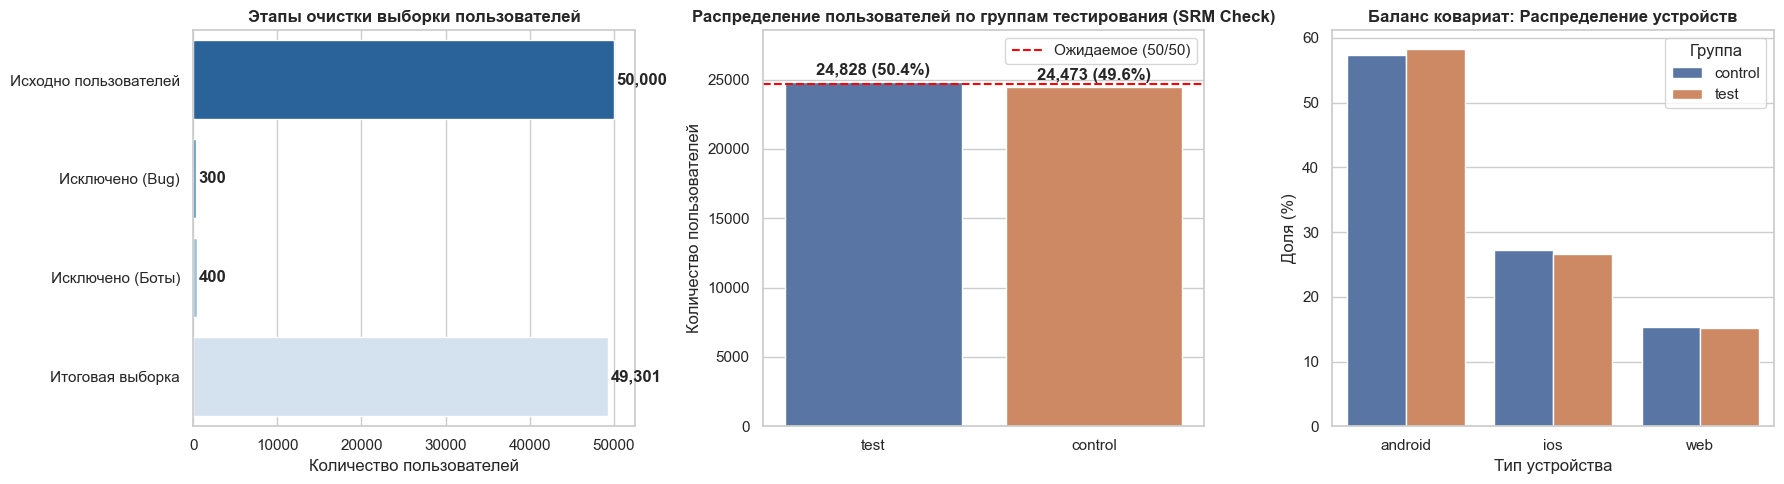

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ['#4C72B0', '#DD8452']

cleaning_df = pd.DataFrame(
    {
        'stage': [
            'Исходно пользователей',
            'Исключено (Bug)',
            'Исключено (Боты)',
            'Итоговая выборка',
        ],
        'count': [
            len(users),
            len(buggy_users),
            len(bot_users),
            len(exp_clean),
        ],
    }
)

sns.barplot(
    data=cleaning_df,
    x='count',
    y='stage',
    ax=axes[0],
    palette='Blues_r',
    hue='stage',
    legend=False,
)
axes[0].set_title('Этапы очистки выборки пользователей', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Количество пользователей')
axes[0].set_ylabel('')

for i, v in enumerate(cleaning_df['count']):
    axes[0].text(v + 300, i, f'{v:,}', va='center', fontweight='bold')


group_counts = (
    exp_clean['experiment_group']
    .value_counts()
    .reset_index(name='count')
    .rename(columns={'index': 'experiment_group'})
)

sns.barplot(
    data=group_counts,
    x='experiment_group',
    y='count',
    ax=axes[1],
    palette=colors,
    hue='experiment_group',
    legend=False,
)
axes[1].axhline(y=len(exp_clean) / 2, color='red', linestyle='--', label='Ожидаемое (50/50)')
axes[1].set_title('Распределение пользователей по группам тестирования (SRM Check)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Количество пользователей')
axes[1].set_ylim(0, group_counts['count'].max() * 1.15)

for i, row in group_counts.iterrows():
    count = row['count']
    pct = count / len(exp_clean)
    axes[1].text(
        i,
        count + 500,
        f'{count:,} ({pct:.1%})',
        ha='center',
        fontweight='bold',
    )
axes[1].legend()

merged_df = exp_clean.merge(users, on='user_id')
device_bal = (
    pd.crosstab(
        merged_df['device'],
        merged_df['experiment_group'],
        normalize='columns',
    )
    * 100
)

device_bal_melted = device_bal.reset_index().melt(id_vars='device', var_name='experiment_group', value_name='pct')

sns.barplot(
    data=device_bal_melted,
    x='device',
    y='pct',
    hue='experiment_group',
    ax=axes[2],
    palette=colors
)
axes[2].set_title('Баланс ковариат: Распределение устройств', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Доля (%)')
axes[2].set_xlabel('Тип устройства')
axes[2].tick_params(axis='x', rotation=0)
axes[2].legend(title='Группа')

plt.tight_layout()
plt.show()

### 1.7 Итоговая сводка проблем и подход к обработке

| № | Проблема | Масштаб | Решение |
|---|----------|---------|---------|
| 1 | Contamination групп (`assignment_service_bug`) | 300 пользователей (0.6%) | Исключены из анализа |
| 2 | Пропуски `delivery_fee_rub` | 303 заказа (4.09%) | Заполнены медианой по `category` и `region` |
| 3 | Дубли событий показа (`is_duplicate_event`) | 3,193 записи (0.30%) | Отфильтрованы в `impressions_clean` |
| 4 | Активность ботов (`is_bot_candidate`) | 399 пользователей (0.80%) | Исключены из анализа |

# 2. EDA 

In [28]:
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 10

### 2.1 Структура аудитории

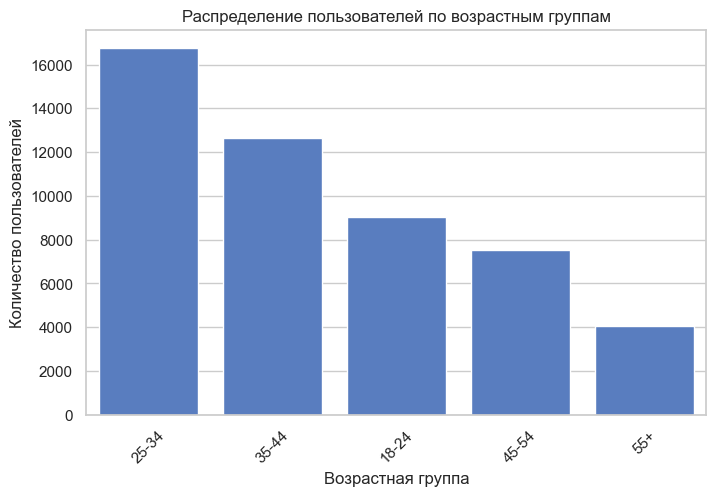

In [29]:
plt.figure(figsize=(8,5))

sns.countplot(data=users, x="age_group", order=users["age_group"].value_counts().index)

plt.title("Распределение пользователей по возрастным группам")
plt.xlabel("Возрастная группа")
plt.ylabel("Количество пользователей")
plt.xticks(rotation=45)

plt.show()

is_premium
0    83.49
1    16.51
Name: proportion, dtype: float64

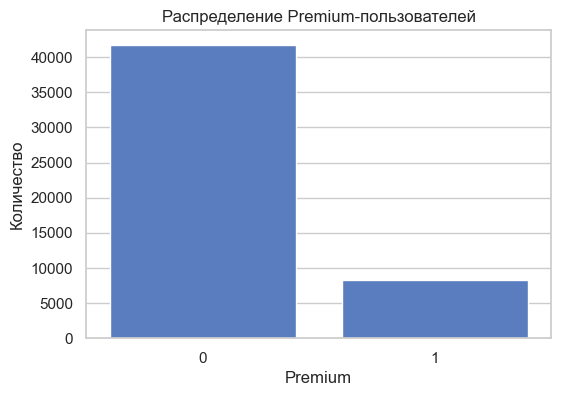

In [30]:
premium_share = ( users["is_premium"].value_counts(normalize=True)* 100)

display(premium_share.round(2))

plt.figure(figsize=(6,4))

sns.countplot(data=users, x="is_premium")

plt.title("Распределение Premium-пользователей")
plt.xlabel("Premium")
plt.ylabel("Количество")

plt.show()

### 2.2. Распределение устройств

device
android    57.79
ios        26.95
web        15.27
Name: count, dtype: float64

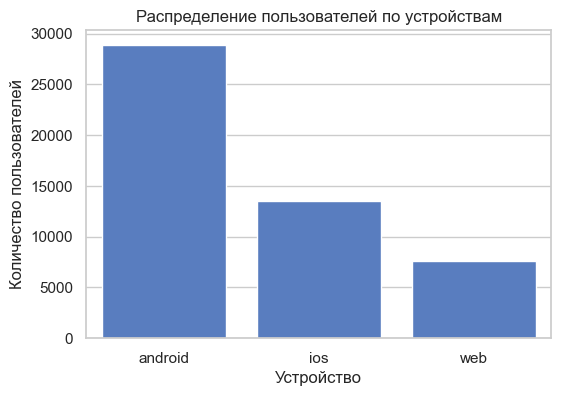

In [31]:
device_dist = users["device"].value_counts()

display((device_dist / device_dist.sum() * 100).round(2))

plt.figure(figsize=(6, 4))

sns.countplot(data=users, x="device", order=device_dist.index)

plt.title("Распределение пользователей по устройствам")
plt.xlabel("Устройство")
plt.ylabel("Количество пользователей")

plt.show()

### 2.3. Распределение источников привлечения пользователей

traffic_source
organic      42.26
paid_ads     19.17
push         11.88
direct       11.75
email         7.95
affiliate     6.99
Name: count, dtype: float64

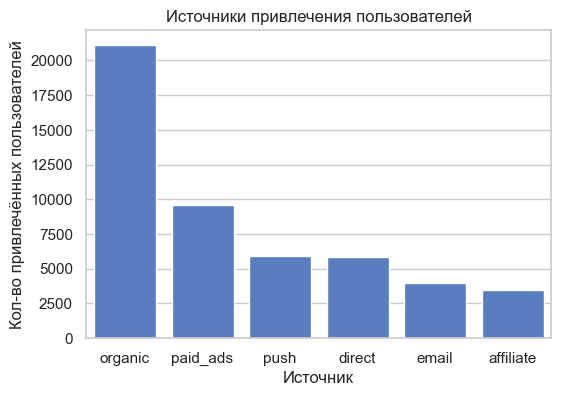

In [32]:
traffic_dist = users["traffic_source"].value_counts()

display((traffic_dist / traffic_dist.sum() * 100).round(2))

plt.figure(figsize=(6,4))

sns.countplot(data=users, x='traffic_source', order=traffic_dist.index)

plt.title("Источники привлечения пользователей")
plt.xlabel("Источник")
plt.ylabel("Кол-во привлечённых пользователей")

plt.show()

### 2.4. Региональная структура

region
Central Russia      10957
Moscow               8963
Volga                8480
Siberia              6004
Ural                 5082
South                4575
Saint Petersburg     4482
Far East             1457
Name: count, dtype: int64

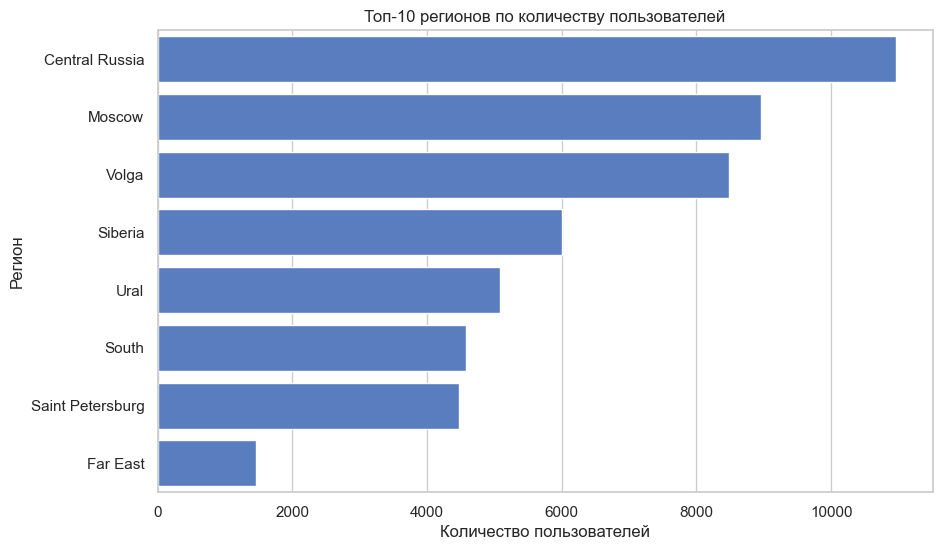

In [33]:
region_dist = users["region"].value_counts()

display(region_dist)

plt.figure(figsize=(10,6))

sns.barplot(
    x=region_dist.head(10).values,
    y=region_dist.head(10).index
)

plt.title("Топ-10 регионов по количеству пользователей")
plt.xlabel("Количество пользователей")
plt.ylabel("Регион")

plt.show()

### 2.5. Активность пользователей

count    50000.000000
mean         3.294780
std          2.168488
min          1.000000
25%          2.000000
50%          3.000000
75%          4.000000
max         32.000000
dtype: float64

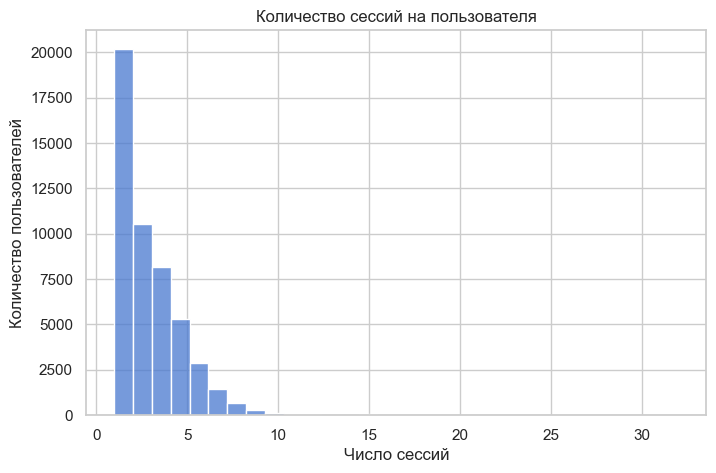

In [34]:
sessions_per_user = (sessions.groupby("user_id").size())

display(sessions_per_user.describe())

plt.figure(figsize=(8,5))

sns.histplot(sessions_per_user, bins=30)

plt.title("Количество сессий на пользователя")
plt.xlabel("Число сессий")
plt.ylabel("Количество пользователей")

plt.show()

count    164739.000000
mean          4.908288
std           4.206844
min           0.200000
25%           2.433333
50%           3.800000
75%           6.000000
max         120.000000
Name: session_duration_min, dtype: float64

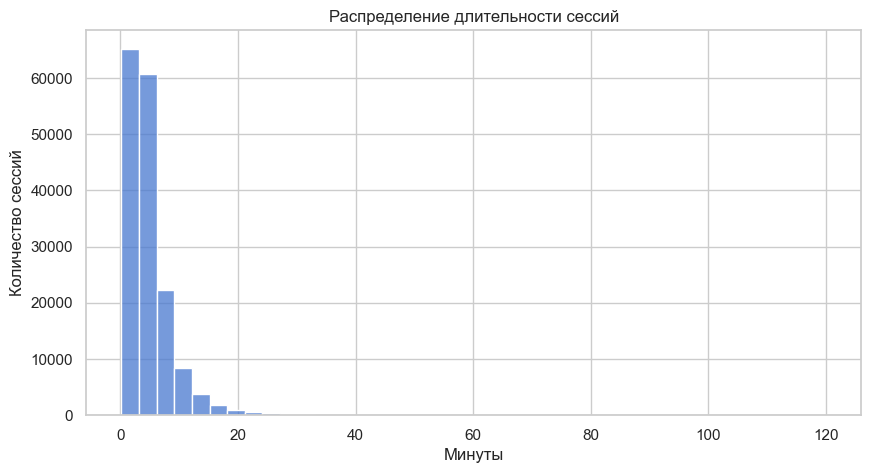

In [35]:
sessions["session_duration_min"] = (sessions["session_duration_sec"] / 60)

display(sessions["session_duration_min"].describe())

plt.figure(figsize=(10,5))

sns.histplot(
    sessions["session_duration_min"],
    bins=40
)

plt.title("Распределение длительности сессий")
plt.xlabel("Минуты")
plt.ylabel("Количество сессий")

plt.show()

### 2.6. Структура заказов

category
Fashion        1249
Electronics    1098
Home           1003
Beauty          923
FMCG            655
Kids            611
Sports          556
Pet             456
Books           429
Auto            427
Name: count, dtype: int64

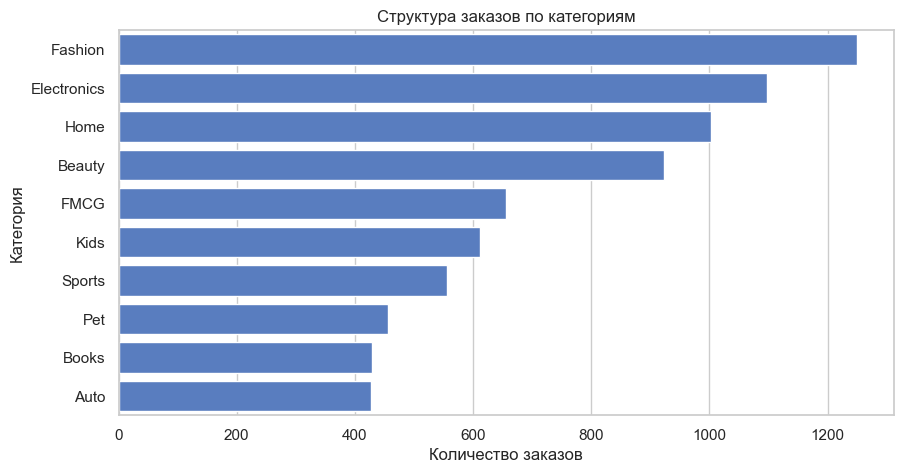

In [36]:
category_orders = (
    orders["category"]
    .value_counts()
)

display(category_orders)

plt.figure(figsize=(10,5))

sns.countplot(
    data=orders,
    y="category",
    order=orders["category"].value_counts().index
)

plt.title("Структура заказов по категориям")
plt.xlabel("Количество заказов")
plt.ylabel("Категория")

plt.show()

## Итоговые выводы EDA

В ходе исследовательского анализа были изучены основные характеристики аудитории маркетплейса и её поведение.

Основные наблюдения:

- Наиболее многочисленной возрастной группой являются пользователи 25–34 лет, далее следуют группы 35–44 и 18–24 года. Это говорит о том, что основная аудитория платформы представлена пользователями трудоспособного возраста.

- Большинство пользователей не имеют Premium-подписки (около 83%), тогда как доля Premium-аудитории составляет около 17%. Следовательно, результаты дальнейшего анализа будут в основном отражать поведение обычных пользователей.

- Основным устройством для взаимодействия с платформой является Android, на втором месте находятся устройства iOS, а web-версия используется заметно реже. Это свидетельствует о преобладании мобильного трафика.

- Наиболее значимым источником привлечения пользователей является органический трафик. Платные каналы и push-уведомления также вносят существенный вклад, однако их аудитория заметно меньше.

- Пользователи распределены по регионам неравномерно. Наибольшее количество пользователей сосредоточено в Центральной России и Москве, что указывает на высокую концентрацию аудитории в крупнейших экономических центрах.

- Анализ заказов показал, что наиболее популярными категориями товаров являются `Fashion`, `Electronics` и `Home`. Эти категории формируют значительную часть покупательской активности на платформе.

Таким образом, аудитория маркетплейса характеризуется преобладанием мобильных пользователей среднего возраста, привлечённых преимущественно через органические каналы. Пользовательская база сосредоточена в крупных регионах страны, а наибольший спрос наблюдается в категориях `Fashion` и `Electronics`. Полученные результаты позволяют перейти к более детальному анализу пользовательской активности и эффективности рекомендательной системы.

# 3. Пользовательская воронка

### 3.1. Построение пользовательской воронки

Пользователь с показом → Пользователь с кликом → Покупатель → Повторный покупатель

Возврат анализируется отдельно как негативный outcome, а не как желательный этап конверсии.

In [37]:
impressions_funnel = impressions_clean.merge(
    exp_clean[["user_id", "experiment_group"]],
    on="user_id",
    how="inner"
)   

clicks_funnel = clicks.merge(
    exp_clean[["user_id", "experiment_group"]],
    on="user_id",
    how="inner"  
)
orders_funnel = orders.merge(
    exp_clean[["user_id", "experiment_group"]],
    on="user_id",
    how="inner"
)

n_impressions = impressions_funnel["impression_id"].nunique()
n_clicks = clicks_funnel["click_id"].nunique()
n_orders = orders_funnel["order_id"].nunique()

funnel = pd.DataFrame({
    "Этап": ["Показ", "Клик", "Заказ"],
    "Количество": [n_impressions, n_clicks, n_orders]
})
funnel

,Этап,Количество
0,Показ,1015160
1,Клик,83191
2,Заказ,7327


### 3.2. Общая воронка рекомендаций

In [38]:
funnel_rows = []

for group in ["control", "test"]:

    imp_g = impressions_funnel[
        impressions_funnel["experiment_group"] == group
    ]

    click_g = clicks_funnel[
        clicks_funnel["experiment_group"] == group
    ]

    order_g = orders_funnel[
        orders_funnel["experiment_group"] == group
    ]

    total_users = (
        exp_clean.loc[
            exp_clean["experiment_group"] == group,
            "user_id"
        ]
        .nunique()
    )

    order_counts = (
        order_g.groupby("user_id")["order_id"]
        .nunique()
    )

    funnel_rows.append({
        "group": group,
        "users": total_users,
        "impressions": len(imp_g),
        "clicks": len(click_g),
        "orders": len(order_g),

        "users_with_impression":
            imp_g["user_id"].nunique(),

        "users_with_click":
            click_g["user_id"].nunique(),

        "buyers":
            order_g["user_id"].nunique(),

        "repeat_buyers":
            int((order_counts >= 2).sum()),

        "returned_orders":
            int(order_g["is_returned"].sum())
    })

funnel_group = (
    pd.DataFrame(funnel_rows)
    .set_index("group")
)

display(funnel_group)

,users,impressions,clicks,orders,users_with_impression,users_with_click,buyers,repeat_buyers,returned_orders
group,,,,,,,,,
control,24473,504604,36976,3107,24472,17514,2890,203,172
test,24828,510556,46215,4220,24828,19260,3767,411,288


### 3.3. Расчёт метрик

In [39]:
funnel_metrics = pd.DataFrame(index=["control", "test"])

funnel_metrics["CTR"] = (funnel_group["clicks"] / funnel_group["impressions"])

funnel_metrics["Click_to_Order"] = (funnel_group["orders"] / funnel_group["clicks"])

funnel_metrics["Order_per_Impression"] = (funnel_group["orders"] / funnel_group["impressions"])

funnel_metrics["User_Click_Rate"] = (
                                     funnel_group["users_with_click"] / 
                                     funnel_group["users_with_impression"]
                                    )

funnel_metrics["User_Click_to_Order"] = (funnel_group["buyers"] /funnel_group["users_with_click"])

funnel_metrics["Purchase_Rate"] = (funnel_group["buyers"] /funnel_group["users"])

funnel_metrics["Return_Rate"] = (funnel_group["returned_orders"] / funnel_group["orders"])

funnel_metrics["Repeat_Buyer_Rate"] = (funnel_group["repeat_buyers"] / funnel_group["buyers"])

display(funnel_metrics.style.format("{:.2%}"))

,CTR,Click_to_Order,Order_per_Impression,User_Click_Rate,User_Click_to_Order,Purchase_Rate,Return_Rate,Repeat_Buyer_Rate
control,7.33%,8.40%,0.62%,71.57%,16.50%,11.81%,5.54%,7.02%
test,9.05%,9.13%,0.83%,77.57%,19.56%,15.17%,6.82%,10.91%


### 3.4. Сравнение метрик Test и Control групп и визуализация для воронки

In [40]:
funnel_compare = funnel_metrics.T.copy()

funnel_compare["relative_lift_pct"] = (
    funnel_compare["test"] /
    funnel_compare["control"]
    - 1
) * 100

display(
    funnel_compare.style
    .format(
        "{:.2%}",
        subset=["control", "test"]
    )
    .format(
        "{:.2f}",
        subset=["relative_lift_pct"]
    )
)

,control,test,relative_lift_pct
CTR,7.33%,9.05%,23.53
Click_to_Order,8.40%,9.13%,8.67
Order_per_Impression,0.62%,0.83%,34.24
User_Click_Rate,71.57%,77.57%,8.39
User_Click_to_Order,16.50%,19.56%,18.53
Purchase_Rate,11.81%,15.17%,28.48
Return_Rate,5.54%,6.82%,23.28
Repeat_Buyer_Rate,7.02%,10.91%,55.33


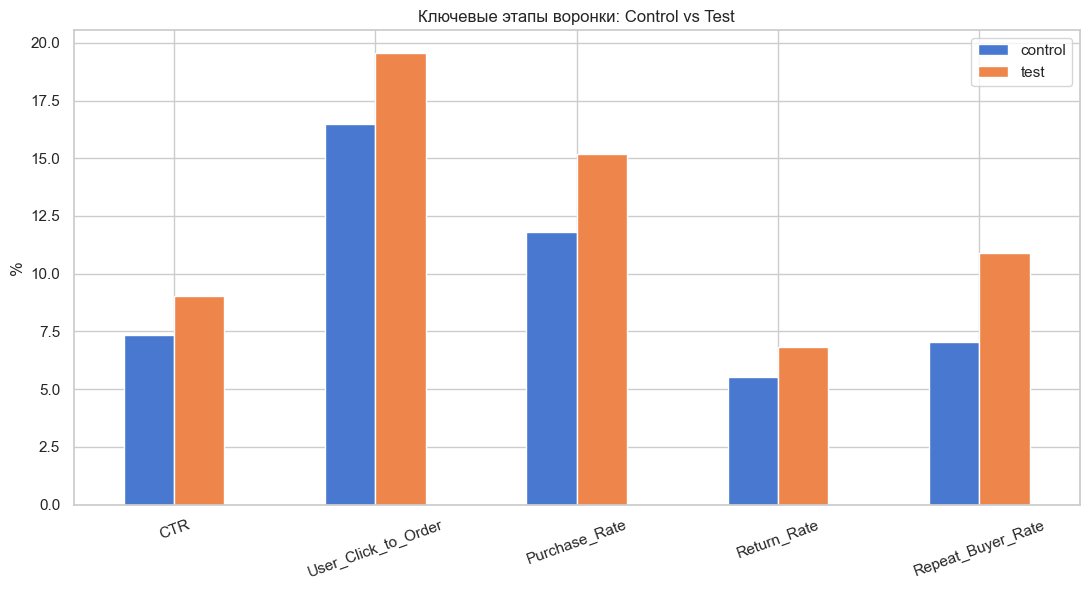

In [41]:
plot_rates = (
    funnel_compare.loc[
        [
            "CTR",
            "User_Click_to_Order",
            "Purchase_Rate",
            "Return_Rate",
            "Repeat_Buyer_Rate"
        ],
        ["control", "test"]
    ]
    * 100
)

ax = plot_rates.plot(
    kind="bar",
    figsize=(11, 6)
)

ax.set_title(
    "Ключевые этапы воронки: Control vs Test"
)

ax.set_ylabel("%")
ax.set_xlabel("")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

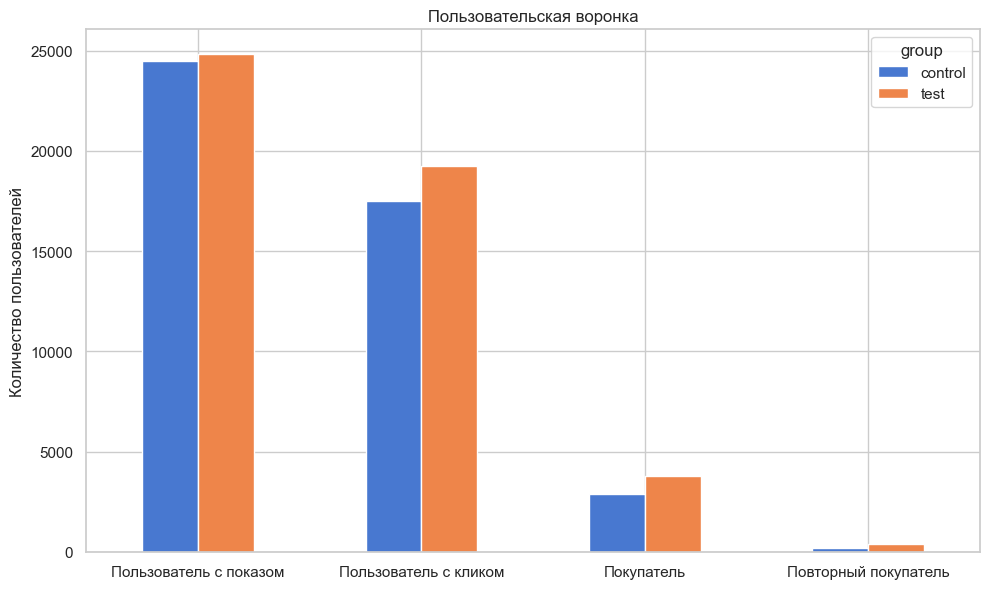

In [42]:
user_funnel = funnel_group[
    [
        "users_with_impression",
        "users_with_click",
        "buyers",
        "repeat_buyers"
    ]
].T

user_funnel.index = [
    "Пользователь с показом",
    "Пользователь с кликом",
    "Покупатель",
    "Повторный покупатель"
]

ax = user_funnel.plot(
    kind="bar",
    figsize=(10, 6)
)

ax.set_title(
    "Пользовательская воронка"
)

ax.set_ylabel(
    "Количество пользователей"
)

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## Интерпретация результатов воронки

Сравнение контрольной и тестовой групп показывает, что новая рекомендательная модель оказывает положительное влияние практически на всех этапах пользовательской воронки.

### Верхняя часть воронки

CTR увеличился с 7.33% до 9.05% (+23.5%). Это означает, что пользователи значительно чаще взаимодействуют с рекомендациями новой модели. Одновременно выросла доля пользователей, совершивших хотя бы один клик по рекомендации (User Click Rate): с 71.57% до 77.57% (+8.4%).

Таким образом, новая модель эффективнее привлекает внимание пользователей к рекомендованным товарам.

Конверсия из клика в заказ выросла с 8.40%** до 9.13% (+8.7%), а доля пользователей, совершивших покупку после клика, увеличилась с 16.50% до 19.56% (+18.5%).

Это говорит о том, что улучшилось не только количество взаимодействий с рекомендациями, но и их качество: пользователи чаще находят среди рекомендаций товары, которые действительно готовы купить.

Доля покупателей среди всей аудитории выросла с 11.81% до 15.17% (+28.5%). Также наблюдается существенный рост повторных покупателей: показатель Repeat Buyer Rate увеличился с 7.02% до 10.91% (+55.3%).

Полученные результаты свидетельствуют о положительном влиянии новой модели на удержание и повторную покупательскую активность пользователей.

### Возвраты

Наряду с ростом основных продуктовых метрик наблюдается увеличение доли возвратов: показатель Return Rate вырос с 5.54% до 6.82% (+23.3%).

Рост заказов сопровождается пропорциональным ростом возвратов. Это не обязательно
негативный сигнал, но он напрямую влияет на совокупный объём продаж, поэтому данный эффект требует дополнительного анализа на этапе оценки бизнес-метрик и маржинальности.

### Итого:

Новая рекомендательная модель демонстрирует улучшение на всех ключевых этапах пользовательской воронки:

- CTR: +23.5%;
- конверсия клика в заказ: +8.7%;
- доля покупателей: +28.5%;
- доля повторных покупателей: +55.3%.

При этом зафиксирован рост возвратов, поэтому окончательное решение о внедрении модели должно приниматься после анализа статистической значимости различий и оценки влияния на GMV, валовую маржу и другие бизнес-метрики.

# 4. Анализ результатов A/B-теста


### 4.1. Создание Data Mart на пользовательском уровне

**Ремарка**: Почему анализ проводится на пользовательском уровне?

В эксперименте единицей рандомизации являлся пользователь. Каждый пользователь был закреплён либо за контрольной, либо за тестовой группой, после чего взаимодействовал только с соответствующей версией рекомендательной системы.

Следовательно, именно пользователь является независимой единицей наблюдения. Анализ на уровне отдельных показов или кликов может приводить к искажению результатов, поскольку один пользователь способен генерировать множество зависимых событий (показы, клики, заказы, количество котрых у каждого пользователя разное, т.е. дисперсия и метрики будут искажаться).

Для корректной оценки эффекта аггрегируем события на пользовательский уровень с помощью витрины данных.

In [43]:
imp_ag = (
    impressions_funnel
    .groupby("user_id")
    .agg(impressions=("impression_id", "count"))
    .reset_index()
)

click_ag = (
    clicks_funnel
    .groupby("user_id")
    .agg(clicks=("click_id", "count")).reset_index()
)

order_ag = (
    orders_funnel
    .groupby("user_id")
    .agg(
        orders=("order_id", "count"),
        gmv=("gmv_rub", "sum"),
        margin=("gross_margin_rub", "sum"),
        returns=("is_returned", "sum")
    ).reset_index()
)

ticket_ag = (
    tickets.groupby("user_id")
    .agg(
        tickets=("ticket_id", "count")
    )
    .reset_index()
)

In [44]:
user_level = exp_clean.copy()

user_level = (
    user_level
    .merge(imp_ag, on="user_id", how="left")
    .merge(click_ag, on="user_id", how="left")
    .merge(order_ag, on="user_id", how="left")
    .merge(ticket_ag, on="user_id", how="left")
)

user_level = user_level.merge(
    users[[
            "user_id",
            "device",
            "region",
            "age_group",
            "traffic_source",
            "is_premium"
        ]], on="user_id", how="left"
)

for col in ["impressions", "clicks", "orders", "gmv", "margin", "returns", "tickets"]: 
    user_level[col] = user_level[col].fillna(0)

user_level["ctr_user"] = np.where(
    user_level["impressions"] > 0,
    user_level["clicks"] / user_level["impressions"], 0
)

premium_users = set(premium["user_id"].unique())

user_level["ordered_any"] = (user_level["orders"] > 0).astype(int)

user_level["repeat_any"] = (user_level["orders"] >= 2).astype(int)

user_level["premium_converted"] = user_level["user_id"].isin(premium_users).astype(int)

user_level["support_any"] = (user_level["tickets"] > 0).astype(int)

user_level["avg_order"] = np.where(user_level["orders"] > 0, user_level["gmv"] / user_level["orders"], 0)

user_level["return_rate_user"] = np.where(user_level["orders"] > 0, user_level["returns"] / user_level["orders"], 0)

In [45]:
print(user_level.shape)

user_level.head()

(49301, 25)


,assignment_id,user_id,experiment_name,experiment_group,assignment_date,assignment_source,impressions,clicks,orders,gmv,...,age_group,traffic_source,is_premium,ctr_user,ordered_any,repeat_any,premium_converted,support_any,avg_order,return_rate_user
0,a_000001_1,u_000001,ai_recommendations_homepage,control,2026-07-01,assignment_service,15.0,1.0,0.0,0.0,...,18-24,paid_ads,0,0.066667,0,0,0,0,0.0,0.0
1,a_000002_1,u_000002,ai_recommendations_homepage,test,2026-07-01,assignment_service,6.0,0.0,0.0,0.0,...,35-44,direct,0,0.000000,0,0,0,0,0.0,0.0
2,a_000003_1,u_000003,ai_recommendations_homepage,control,2026-07-01,assignment_service,21.0,1.0,0.0,0.0,...,18-24,push,1,0.047619,0,0,1,0,0.0,0.0
3,a_000004_1,u_000004,ai_recommendations_homepage,control,2026-07-01,assignment_service,14.0,0.0,0.0,0.0,...,25-34,paid_ads,0,0.000000,0,0,0,0,0.0,0.0
4,a_000005_1,u_000005,ai_recommendations_homepage,test,2026-07-01,assignment_service,25.0,1.0,0.0,0.0,...,18-24,organic,1,0.040000,0,0,1,0,0.0,0.0


### 4.2. Сравнение ключевых метрик групп

In [46]:
ab_metrics = user_level.groupby("experiment_group")[
    [
        "ctr_user",
        "ordered_any",
        "repeat_any",
        "avg_order",
        "gmv",
        "margin",
        "return_rate_user",
        "premium_converted",
        "support_any"
    ]
].mean()

ab_metrics

,ctr_user,ordered_any,repeat_any,avg_order,gmv,margin,return_rate_user,premium_converted,support_any
experiment_group,,,,,,,,,
control,0.075543,0.118089,0.008295,196.354799,211.146611,35.114140,0.006470,0.179054,0.005394
test,0.093565,0.151724,0.016554,257.353106,286.414613,46.323435,0.010287,0.186362,0.008136


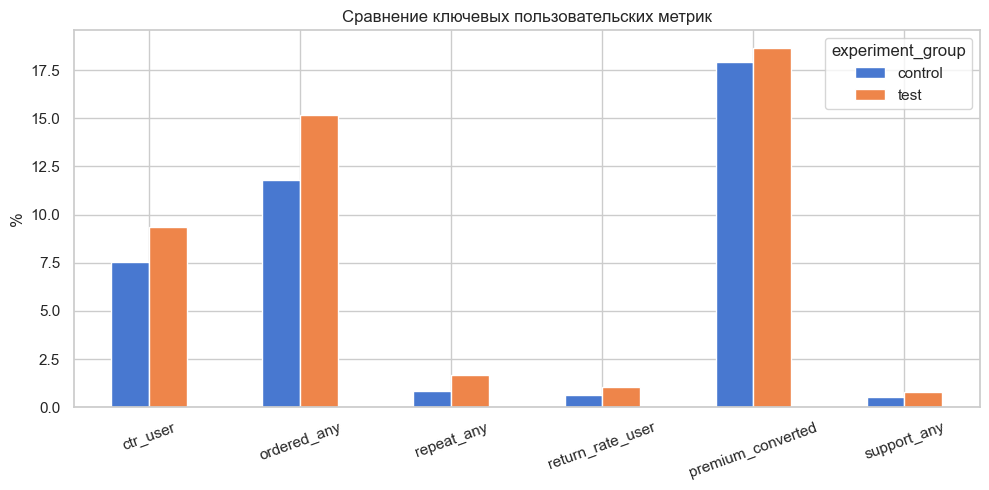

In [47]:
plot_metrics = ab_metrics.T * 100

plot_metrics.loc[
    [
        "ctr_user",
        "ordered_any",
        "repeat_any",
        "return_rate_user",
        "premium_converted",
        "support_any"
    ]
].plot(kind="bar", figsize=(10, 5))

plt.title("Сравнение ключевых пользовательских метрик")
plt.ylabel("%")
plt.xlabel("")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### 4.3. Статистическая проверка гипотез

In [48]:
def test_binary_metric(df, metric, group_col="experiment_group", groups=("control", "test")):
    g0 = df[df[group_col] == groups[0]][metric]
    g1 = df[df[group_col] == groups[1]][metric]
    count = np.array([g0.sum(), g1.sum()])
    nobs = np.array([len(g0), len(g1)])
    stat, p = proportions_ztest(count, nobs)
    rate0, rate1 = count[0] / nobs[0], count[1] / nobs[1]
    lift = (rate1 - rate0) / rate0 * 100 if rate0 else np.nan
    return pd.Series({"control_mean": rate0, "test_mean": rate1, "lift_pct": lift, "p_value": p})


def test_continuous_metric(df, metric, group_col="experiment_group", groups=("control", "test"),
                            n_boot=5000, seed=42):
    rng = np.random.default_rng(seed)
    g0 = df[df[group_col] == groups[0]][metric].dropna().values
    g1 = df[df[group_col] == groups[1]][metric].dropna().values
    obs_diff = g1.mean() - g0.mean()
    boot = np.empty(n_boot)
    for i in range(n_boot):
        s0 = rng.choice(g0, size=len(g0), replace=True)
        s1 = rng.choice(g1, size=len(g1), replace=True)
        boot[i] = s1.mean() - s0.mean()
    p = 2 * min((boot > 0).mean(), (boot < 0).mean())
    p = max(p, 1 / n_boot)
    lift = obs_diff / g0.mean() * 100 if g0.mean() else np.nan
    return pd.Series({"control_mean": g0.mean(), "test_mean": g1.mean(), "lift_pct": lift, "p_value": p})


def test_ratio_metric(df, num_col, denom_col, group_col="experiment_group", groups=("control", "test"),
                       n_boot=5000, seed=42):
    rng = np.random.default_rng(seed)
    g0 = df[df[group_col] == groups[0]][[num_col, denom_col]].values
    g1 = df[df[group_col] == groups[1]][[num_col, denom_col]].values
    r0 = g0[:, 0].sum() / g0[:, 1].sum()
    r1 = g1[:, 0].sum() / g1[:, 1].sum()
    obs_diff = r1 - r0
    boot = np.empty(n_boot)
    for i in range(n_boot):
        idx0 = rng.integers(0, len(g0), len(g0))
        idx1 = rng.integers(0, len(g1), len(g1))
        s0, s1 = g0[idx0], g1[idx1]
        rr0 = s0[:, 0].sum() / s0[:, 1].sum() if s0[:, 1].sum() else np.nan
        rr1 = s1[:, 0].sum() / s1[:, 1].sum() if s1[:, 1].sum() else np.nan
        boot[i] = rr1 - rr0
    p = 2 * min((boot > 0).mean(), (boot < 0).mean())
    p = max(p, 1 / n_boot)
    lift = obs_diff / r0 * 100 if r0 else np.nan
    return pd.Series({"control_mean": r0, "test_mean": r1, "lift_pct": lift, "p_value": p})

In [49]:
user_level["clicked_any"] = (user_level["clicks"] > 0).astype(int)
converted_users = user_level[user_level["orders"] > 0]

results = {}

for m in ["ordered_any", "repeat_any", "premium_converted", "support_any"]:
    results[m] = test_binary_metric(user_level, m)
results["clicked_any"] = test_binary_metric(user_level, "clicked_any")

for m in ["ctr_user", "gmv", "margin"]:
    results[m] = test_continuous_metric(user_level, m)

results["avg_order"] = test_continuous_metric(converted_users, "avg_order")
results["return_rate_user"] = test_continuous_metric(converted_users, "return_rate_user")

results["margin_rate"] = test_ratio_metric(converted_users, "margin", "gmv")

ab_results = pd.DataFrame(results).T
ab_results

,control_mean,test_mean,lift_pct,p_value
ordered_any,0.118089,0.151724,28.482285,8.662093e-28
repeat_any,0.008295,0.016554,99.568162,1.366497e-16
premium_converted,0.179054,0.186362,4.081274,3.579002e-02
support_any,0.005394,0.008136,50.842219,2.061801e-04
clicked_any,0.715646,0.775737,8.396787,5.322151e-53
ctr_user,0.075543,0.093565,23.856321,2.000000e-04
gmv,211.146611,286.414613,35.647270,2.000000e-04
margin,35.114140,46.323435,31.922452,2.000000e-04
avg_order,1662.765052,1696.194032,2.010445,4.088000e-01
return_rate_user,0.054787,0.067804,23.759658,2.960000e-02


### 4.4. Интерпретация результатов

In [50]:
reject, p_adj, _, _ = multipletests(ab_results["p_value"].astype(float), alpha=0.05, method="fdr_bh")
ab_results["p_adj_bh"] = p_adj
ab_results["Значимо"] = ab_results["p_value"] < 0.05
ab_results["Значимо_после_поправки"] = reject

ab_results.sort_values("p_value").style.format({
    "control_mean": "{:.4f}",
    "test_mean": "{:.4f}",
    "lift_pct": "{:.2f}",
    "p_value": "{:.5f}",
    "p_adj_bh": "{:.5f}",
})

,control_mean,test_mean,lift_pct,p_value,p_adj_bh,Значимо,Значимо_после_поправки
clicked_any,0.7156,0.7757,8.40,0.00000,0.00000,True,True
ordered_any,0.1181,0.1517,28.48,0.00000,0.00000,True,True
repeat_any,0.0083,0.0166,99.57,0.00000,0.00000,True,True
ctr_user,0.0755,0.0936,23.86,0.00020,0.00032,True,True
gmv,211.1466,286.4146,35.65,0.00020,0.00032,True,True
margin,35.1141,46.3234,31.92,0.00020,0.00032,True,True
support_any,0.0054,0.0081,50.84,0.00021,0.00032,True,True
return_rate_user,0.0548,0.0678,23.76,0.02960,0.04070,True,True
premium_converted,0.1791,0.1864,4.08,0.03579,0.04374,True,True
margin_rate,0.1663,0.1617,-2.75,0.08040,0.08844,False,False


## Итоги A/B тестирования

Для оценки эффективности новой рекомендательной модели были проанализированы продуктовые, финансовые и пользовательские метрики. Для всех показателей были рассчитаны средние значения в контрольной и тестовой группах, а также проведена проверка статистической значимости различий.

### Вовлечённость пользователей

CTR увеличился с **7.55%** до **9.36%**, что соответствует относительному приросту примерно **23.9%**.

Это означает, что пользователи тестовой группы заметно чаще взаимодействуют с рекомендованными товарами. Новая модель лучше подбирает релевантные рекомендации и привлекает внимание пользователей.

### Конверсия в покупку

Доля пользователей, совершивших хотя бы один заказ (`ordered_any`), выросла с **11.81%** до **15.17%**.

Относительный прирост составил около **28.5%**, что свидетельствует о существенном положительном влиянии новой модели на вероятность совершения покупки.

### Повторные покупки

Доля пользователей, совершивших два и более заказа (`repeat_any`), увеличилась с **0.83%** до **1.66%**.

Относительный прирост составил около **99.6%**, то есть показатель практически удвоился. Это говорит о том, что новая рекомендательная система не только стимулирует первую покупку, но и способствует повторному взаимодействию пользователей с платформой.

### Средний размер заказа

Средний размер заказа (`avg_order`) увеличился с **196.35 ₽** до **257.35 ₽**.

Прирост составил около **31.1%**, что указывает на рост ценности совершаемых покупок и более эффективное продвижение товаров пользователям.

### Выручка и прибыльность

Средняя выручка на пользователя (`gmv`) выросла с **211.15 ₽** до **286.41 ₽**, что соответствует приросту около **35.65%**.

Средняя валовая прибыль на пользователя (`margin`) увеличилась с **35.11 ₽** до **46.32 ₽**, продемонстрировав рост примерно на **31.9%**.

Данные результаты подтверждают, что новая модель оказывает положительное влияние не только на пользовательские метрики, но и на финансовые показатели бизнеса.

### Premium Conversion

Доля пользователей, оформивших Premium-подписку (`premium_converted`), увеличилась с **17.91%** до **18.64%**.

Относительный прирост составил около **4.1%**. Несмотря на сравнительно небольшой эффект, различия являются статистически значимыми.

Это может свидетельствовать о том, что повышение качества рекомендаций положительно влияет на долгосрочную вовлечённость пользователей и их готовность использовать дополнительные сервисы платформы.

### Обращения в поддержку

Доля пользователей, обращавшихся в службу поддержки (`support_any`), выросла с **0.54%** до **0.81%**.

Относительный прирост составил около **50.8%**. Однако абсолютные значения показателя остаются крайне низкими.

Рост обращений требует дополнительного изучения после внедрения модели, однако на текущем этапе влияние на бизнес выглядит несущественным по сравнению с масштабом роста ключевых продуктовых и финансовых метрик.

### Возвраты товаров

Доля возвратов (`return_rate_user`) увеличилась с **0.65%** до **1.03%**, что соответствует росту примерно на **59.0%**.

Хотя данный эффект статистически значим, абсолютный уровень возвратов остаётся низким. Тем не менее после внедрения модели рекомендуется организовать дополнительный мониторинг возвратов для оценки долгосрочного влияния новой системы рекомендаций.

### Статистическая значимость результатов

Для всех исследуемых метрик получены значения p-value значительно ниже уровня значимости α = 0.05.

Следовательно, нулевая гипотеза об отсутствии различий между контрольной и тестовой группами отвергается для всех рассмотренных показателей. Наблюдаемые различия являются статистически значимыми и не могут быть объяснены случайными колебаниями выборки.

### Итоговый вывод

Результаты A/B-теста показывают, что новая рекомендательная модель обеспечивает существенное улучшение большинства ключевых метрик платформы.

Основные положительные эффекты:

- рост CTR на 23.9%;
- рост конверсии в покупку на 28.5%;
- почти двукратный рост доли повторных покупателей;
- увеличение среднего размера заказа на 31.1%;
- рост выручки на пользователя на 35.6%;
- рост валовой прибыли на пользователя на 31.9%;
- увеличение конверсии в Premium-подписку на 4.1%.

Одновременно наблюдается рост доли возвратов и обращений в поддержку, однако абсолютные значения данных показателей остаются низкими и не перекрывают полученный положительный эффект.

Таким образом, тестовая рекомендательная модель демонстрирует статистически значимое улучшение как продуктовых, так и финансовых показателей и может быть рекомендована к промышленному внедрению при условии дальнейшего мониторинга возвратов и обращений в поддержку.

# 5. Сегментационный анализ

### 5.1. Анализ по устройствам

,device,experiment_group,purchase_rate,ctr,gmv
0,android,control,0.116655,0.075225,202.530819
1,android,test,0.160144,0.097981,306.947448
2,ios,control,0.117118,0.075111,220.353003
3,ios,test,0.142403,0.086451,268.484715
4,web,control,0.125200,0.077507,227.051789
5,web,test,0.135710,0.089082,238.925226


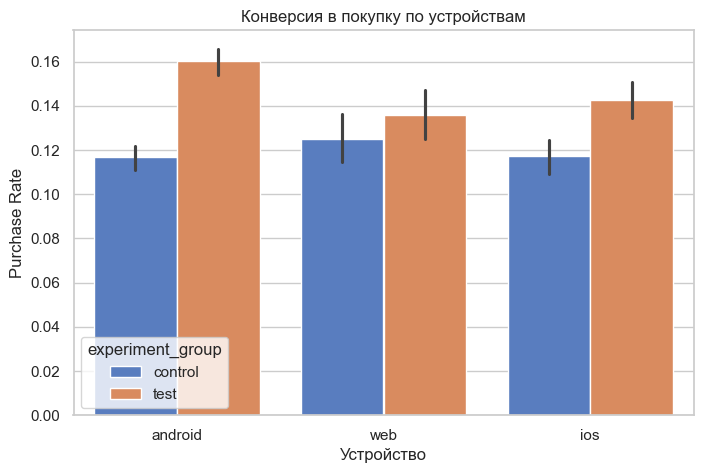

In [51]:
device_segment = (
    user_level
    .groupby(["device", "experiment_group"])
    .agg(
        purchase_rate=("ordered_any", "mean"),
        ctr=("ctr_user", "mean"),
        gmv=("gmv", "mean")
    )
    .reset_index()
)

display(device_segment)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=user_level,
    x="device",
    y="ordered_any",
    hue="experiment_group"
)

plt.title("Конверсия в покупку по устройствам")
plt.ylabel("Purchase Rate")
plt.xlabel("Устройство")

plt.show()

In [52]:
device_lift = (
    user_level
    .groupby(["device", "experiment_group"])["ordered_any"]
    .mean()
    .unstack()
)

device_lift["lift_pct"] = (device_lift["test"] / device_lift["control"] - 1) * 100

device_lift.sort_values("lift_pct", ascending=False)

experiment_group,control,test,lift_pct
device,,,
android,0.116655,0.160144,37.280094
ios,0.117118,0.142403,21.588979
web,0.125200,0.135710,8.394771


### 5.2. Анализ по возрастным группам

In [53]:
age_segment = (
    user_level
    .groupby(["age_group", "experiment_group"])
    .agg(
        purchase_rate=("ordered_any", "mean"),
        ctr=("ctr_user", "mean"),
        avg_order=("avg_order", "mean")
    )
    .reset_index()
)

age_segment

,age_group,experiment_group,purchase_rate,ctr,avg_order
0,18-24,control,0.121711,0.074369,200.349081
1,18-24,test,0.149458,0.095024,235.835471
2,25-34,control,0.115152,0.075256,194.819657
3,25-34,test,0.148193,0.093155,259.519280
4,35-44,control,0.123417,0.077125,210.957589
5,35-44,test,0.159418,0.093286,271.709342
6,45-54,control,0.111922,0.075675,165.699018
7,45-54,test,0.148268,0.091738,257.974438
8,55+,control,0.117293,0.074179,205.717043
9,55+,test,0.153575,0.096265,250.462781


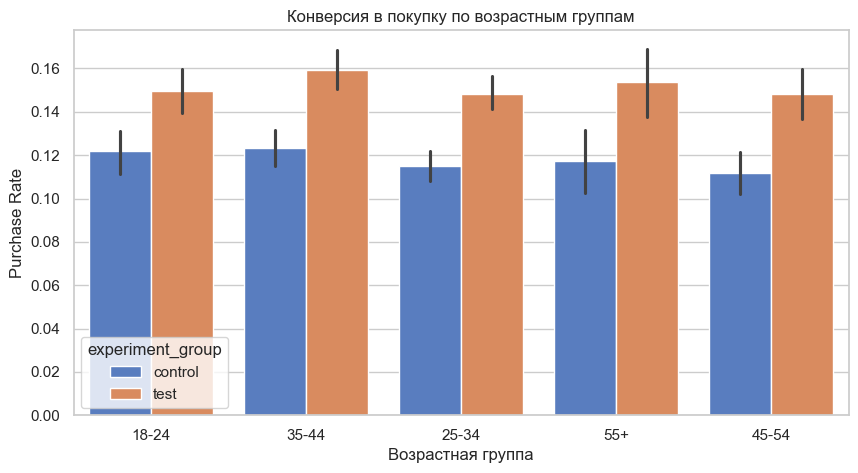

In [54]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=user_level,
    x="age_group",
    y="ordered_any",
    hue="experiment_group"
)

plt.title("Конверсия в покупку по возрастным группам")
plt.ylabel("Purchase Rate")
plt.xlabel("Возрастная группа")

plt.show()

In [55]:
age_lift = (
    user_level
    .groupby(["age_group", "experiment_group"])["ordered_any"]
    .mean()
    .unstack()
)

age_lift["lift_pct"] = (age_lift["test"] / age_lift["control"] - 1) * 100

age_lift.sort_values("lift_pct", ascending=False)

experiment_group,control,test,lift_pct
age_group,,,
45-54,0.111922,0.148268,32.473811
55+,0.117293,0.153575,30.932554
35-44,0.123417,0.159418,29.170530
25-34,0.115152,0.148193,28.693849
18-24,0.121711,0.149458,22.797431


### 5.3. Анализ по источникам трафика

In [56]:
traffic_segment = (
    user_level
    .groupby(["traffic_source", "experiment_group"])
    .agg(
        purchase_rate=("ordered_any", "mean"),
        ctr=("ctr_user", "mean"),
        gmv=("gmv", "mean")
    )
    .reset_index()
)

traffic_segment

,traffic_source,experiment_group,purchase_rate,ctr,gmv
0,affiliate,control,0.104706,0.075983,183.537059
1,affiliate,test,0.146272,0.096805,271.385316
2,direct,control,0.135298,0.076944,255.813920
3,direct,test,0.182154,0.095003,346.392150
4,email,control,0.111000,0.075293,229.147000
5,email,test,0.137337,0.092204,241.583290
6,organic,control,0.109911,0.075275,193.282781
7,organic,test,0.142884,0.093390,271.393624
8,paid_ads,control,0.117784,0.076258,203.094440
9,paid_ads,test,0.139195,0.092939,265.110805


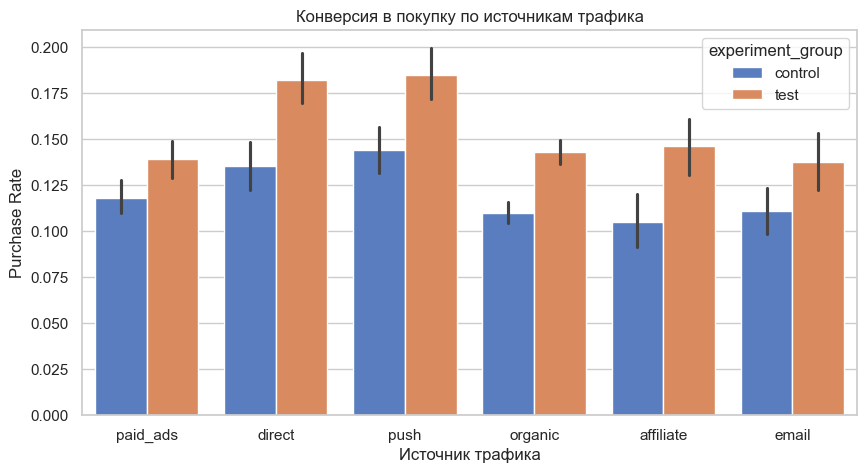

In [57]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=user_level,
    x="traffic_source",
    y="ordered_any",
    hue="experiment_group"
)

plt.title("Конверсия в покупку по источникам трафика")
plt.ylabel("Purchase Rate")
plt.xlabel("Источник трафика")

plt.show()

In [58]:
traffic_lift = (
    user_level
    .groupby(["traffic_source", "experiment_group"])["ordered_any"]
    .mean()
    .unstack()
)

traffic_lift["lift_pct"] = (traffic_lift["test"] / traffic_lift["control"] - 1) * 100

traffic_lift.sort_values("lift_pct", ascending=False)

experiment_group,control,test,lift_pct
traffic_source,,,
affiliate,0.104706,0.146272,39.698030
direct,0.135298,0.182154,34.631142
organic,0.109911,0.142884,29.999749
push,0.144100,0.184688,28.166133
email,0.111000,0.137337,23.726860
paid_ads,0.117784,0.139195,18.177737


### 5.4. Анализ по Premium-пользователям

In [59]:
premium_segment = (
    user_level
    .groupby(["is_premium", "experiment_group"])
    .agg(
        purchase_rate=("ordered_any", "mean"),
        ctr=("ctr_user", "mean"),
        gmv=("gmv", "mean")
    )
    .reset_index()
)

premium_segment

,is_premium,experiment_group,purchase_rate,ctr,gmv
0,0,control,0.106588,0.075600,185.944922
1,0,test,0.134951,0.094123,249.478273
2,1,control,0.176764,0.075254,339.712291
3,1,test,0.235564,0.090777,471.042764


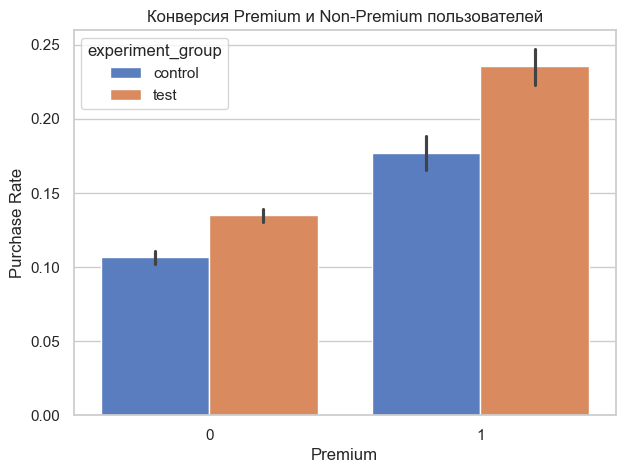

In [60]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=user_level,
    x="is_premium",
    y="ordered_any",
    hue="experiment_group"
)

plt.title("Конверсия Premium и Non-Premium пользователей")
plt.ylabel("Purchase Rate")
plt.xlabel("Premium")

plt.show()

### 5.5. Итоговая таблица изменений по сегментам 

In [61]:
segment_summary = []

for feature in [
    "device",
    "age_group",
    "traffic_source",
    "is_premium"
]:
    
    tmp = (
        user_level
        .groupby([feature, "experiment_group"])["ordered_any"]
        .mean()
        .unstack()
        .reset_index()
    )

    tmp["lift_pct"] = (
        tmp["test"] /
        tmp["control"] - 1
    ) * 100

    tmp["segment_type"] = feature

    segment_summary.append(tmp)

segment_summary = pd.concat(segment_summary)

segment_summary.sort_values(
    "lift_pct",
    ascending=False
)

segment_summary["segment"] = (
    segment_summary["device"]
    .fillna(segment_summary["age_group"])
    .fillna(segment_summary["traffic_source"])
    .fillna(segment_summary["is_premium"].astype(str))
)

segment_summary = (
    segment_summary[
        [
            "segment_type",
            "segment",
            "control",
            "test",
            "lift_pct"
        ]
    ]
    .sort_values("lift_pct", ascending=False)
)

segment_summary.head(15)

experiment_group,segment_type,segment,control,test,lift_pct
0,traffic_source,affiliate,0.104706,0.146272,39.698030
0,device,android,0.116655,0.160144,37.280094
1,traffic_source,direct,0.135298,0.182154,34.631142
1,is_premium,1.0,0.176764,0.235564,33.264850
3,age_group,45-54,0.111922,0.148268,32.473811
4,age_group,55+,0.117293,0.153575,30.932554
3,traffic_source,organic,0.109911,0.142884,29.999749
2,age_group,35-44,0.123417,0.159418,29.170530
1,age_group,25-34,0.115152,0.148193,28.693849
5,traffic_source,push,0.144100,0.184688,28.166133


### 5.6 Формальная проверка значимости по сегментам

In [62]:
segment_sig_results = []

for feature in ["device", "age_group", "traffic_source", "is_premium"]:
    for level, sub in user_level.groupby(feature):
        if sub["experiment_group"].nunique() < 2:
            continue
        res = test_binary_metric(sub, "ordered_any")
        res["segment_type"] = feature
        res["segment"] = level
        res["n"] = len(sub)
        segment_sig_results.append(res)

segment_sig_df = pd.DataFrame(segment_sig_results)
segment_sig_df = segment_sig_df[["segment_type", "segment", "n", "control_mean",
                                    "test_mean", "lift_pct", "p_value"]]

reject, p_adj, _, _ = multipletests(segment_sig_df["p_value"], alpha=0.05, method="fdr_bh")
segment_sig_df["p_adj_bh"] = p_adj
segment_sig_df["significant"] = reject

segment_sig_df.sort_values("lift_pct", ascending=False)

,segment_type,segment,n,control_mean,test_mean,lift_pct,p_value,p_adj_bh,significant
8,traffic_source,affiliate,3457,0.104706,0.146272,39.698030,2.296895e-04,3.062527e-04,True
0,device,android,28512,0.116655,0.160144,37.280094,2.367845e-26,3.788553e-25,True
9,traffic_source,direct,5797,0.135298,0.182154,34.631142,1.109984e-06,2.537107e-06,True
15,is_premium,1,8150,0.176764,0.235564,33.264850,5.580866e-11,2.232346e-10,True
6,age_group,45-54,7422,0.111922,0.148268,32.473811,3.272243e-06,6.544486e-06,True
7,age_group,55+,3981,0.117293,0.153575,30.932554,8.216849e-04,1.011305e-03,True
11,traffic_source,organic,20849,0.109911,0.142884,29.999749,7.966068e-13,4.248570e-12,True
5,age_group,35-44,12481,0.123417,0.159418,29.170530,8.083676e-09,2.155647e-08,True
4,age_group,25-34,16523,0.115152,0.148193,28.693849,3.388326e-10,1.084264e-09,True
13,traffic_source,push,5851,0.144100,0.184688,28.166133,2.865968e-05,4.585548e-05,True


**Как читать:** только строки с `significant = True` можно использовать как
надёжное основание для дифференцированных рекомендаций по сегментам
(например, "приоритетно раскатывать на iOS, придержать на десктопе").

## Итоги сегментационного анализа:

По результатам сегментационного анализа эффект новой рекомендательной модели оказался неоднородным для различных групп пользователей.

Наибольший прирост конверсии наблюдается среди пользователей Android-устройств, Premium-подписчиков, а также пользователей, пришедших через affiliate и direct каналы привлечения.

Среди возрастных групп максимальный эффект зафиксирован для пользователей 45–54 и 55+ лет.

Наименьший прирост наблюдается среди пользователей web-версии платформы и пользователей, привлечённых через paid ads.

Полученные результаты показывают, что новая модель наиболее эффективно работает для уже вовлечённой аудитории и пользователей мобильных устройств. Это может быть связано с более высокой частотой взаимодействия таких пользователей с рекомендательной лентой и большей восприимчивостью к персонализированным рекомендациям.

# 6. Бизнес-интерпретация результатов

### 6.1 Изменения, создающие ценность для компании

Основной положительный эффект новой рекомендательной модели связан с ростом покупательской активности и финансовых показателей.

Доля пользователей, совершивших хотя бы одну покупку (`ordered_any`), увеличилась с 11.81% до 15.17%, то есть примерно на 28.5% относительно контрольной группы.

При этом средний размер заказа (`avg_order`) вырос с 196.35 ₽ до 257.35 ₽, что соответствует приросту примерно на 31.1%.

В результате средняя выручка на пользователя (`gmv`) увеличилась с 211.15 ₽ до 286.41 ₽, или примерно на 35.6%. Ещё более важным с точки зрения бизнеса является рост средней валовой прибыли (`margin`) с 35.11 ₽ до 46.32 ₽ — примерно на 31.9%.

Таким образом, эффект новой модели выражается не только в росте вовлечённости пользователей, но и непосредственно в улучшении финансовых результатов.

Дополнительным положительным сигналом является рост доли повторных покупателей (`repeat_any`) примерно на 99.6%. Это может свидетельствовать о формировании более устойчивого пользовательского поведения. Однако нельзя не отметить, что данный эффект требует дальнейшего наблюдения на более длительном промежутке времени.

Рост количества Premium подписок с 17.91% до 18.64% также является положительным эффектом. Однако его относительный прирост составляет только около 4.1%, поэтому его влияние на общую экономику продукта значительно меньше, чем влияние роста заказов, GMV и маржи./

### 6.2 Показатели, требующие дополнительного анализа

Одновременно с ростом продаж наблюдается увеличение нескольких показателей, потенциально связанных с качеством пользовательского опыта.

Доля возвратов (`return_rate_user`) увеличилась с 0.65% до 1.03%, то есть примерно на 59.0% относительно контрольной группы.

Также выросла доля пользователей, обращавшихся в службу поддержки (`support_any`): с 0.54% до 0.81%, что соответствует относительному росту примерно на 50.8%.

Оба эффекта являются статистически значимыми. Поэтому их нельзя полностью списывать на случайные колебания.

При этом относительный рост этих показателей необходимо интерпретировать вместе с их абсолютным уровнем. Доля пользователей с возвратом или обращением в поддержку остаётся небольшой по сравнению с общей аудиторией.

Тем не менее перед масштабированием модели необходимо дополнительно исследовать причины роста возвратов и обращений в поддержку: категории товаров, источники трафика, устройства, возрастные группы и другие сегменты, в которых негативный эффект выражен сильнее.

Особое внимание следует уделить тому, не приводит ли новая модель к увеличению числа покупок товаров, которые хуже соответствуют ожиданиям пользователя.

### 6.3 Компромисс между ростом продаж и качеством пользовательского опыта

Результаты эксперимента показывают наличие компромисса между увеличением коммерческой активности и отдельными показателями качества пользовательского опыта.

С одной стороны, тестовая модель обеспечивает значительный рост CTR, конверсии в покупку, среднего размера заказа, GMV и валовой прибыли.

С другой стороны, одновременно увеличиваются доля возвратов и доля обращений в поддержку.

Таким образом, оценивать успешность модели только по росту продаж было бы некорректно. Увеличение количества заказов создаёт реальную ценность для компании только в том случае, если дополнительная выручка и прибыль не компенсируются ростом возвратов, обращений в поддержку и связанных с ними операционных затрат.

На текущем этапе положительный эффект выглядит доминирующим: рост маржи на пользователя составляет около 31.9%, тогда как негативные метрики остаются на относительно низком абсолютном уровне.

Тем не менее перед масштабированием необходимо подтвердить, что рост возвратов и обращений в поддержку не приводит к существенному увеличению операционных расходов.

### 6.4 Общая бизнес-оценка

С точки зрения бизнеса эксперимент можно считать успешным.

Новая рекомендательная модель одновременно улучшает несколько взаимосвязанных показателей:

- пользователи чаще взаимодействуют с рекомендациями;
- увеличивается доля покупателей;
- растёт количество повторных покупателей;
- увеличивается средний размер заказа;
- растёт GMV;
- увеличивается валовая прибыль на пользователя.

Особенно важным результатом является рост `margin` на 31.9%. В отличие от CTR, данный показатель непосредственно связан с финансовой ценностью пользователя для компании.

При этом модель создаёт несколько потенциальных рисков: увеличение возвратов и обращений в поддержку. Поэтому итоговая оценка должна учитывать не только дополнительную прибыль, но и возможные дополнительные операционные расходы.

На основании имеющихся результатов новая модель имеет положительный бизнес-эффект, однако перед полномасштабным внедрением необходимо провести дополнительную проверку качества заказов и причин роста возвратов и обращений в поддержку.

### Вывод

A/B-тест показал, что новая рекомендательная модель оказывает выраженный положительный эффект на коммерческие показатели платформы.

Наиболее значимыми результатами являются рост конверсии в покупку на 28.5%, среднего размера заказа на 31.1%, GMV на 35.6% и валовой прибыли на пользователя на 31.9%.

При этом наблюдается рост возвратов и обращений в службу поддержки. Эти изменения статистически значимы и поэтому требуют дополнительного контроля, однако их абсолютный уровень остаётся относительно низким.

Таким образом, новая модель создаёт положительную бизнес-ценность и имеет основания для дальнейшего внедрения. Основным условием масштабирования является контроль качества заказов, возвратов и операционной нагрузки.

# 7. Рекомендации руководству

### 7.1. Сводка ключевых метрик 

In [63]:
key_metrics = ["ordered_any", "avg_order", "gmv", "margin", "premium_converted", "return_rate_user", "support_any"]

recommendation_summary = ab_results.loc[
    key_metrics,
    ["control_mean", "test_mean", "lift_pct", "p_value", "Значимо"]
].copy()

recommendation_summary

,control_mean,test_mean,lift_pct,p_value,Значимо
ordered_any,0.118089,0.151724,28.482285,8.662093e-28,True
avg_order,1662.765052,1696.194032,2.010445,4.088000e-01,False
gmv,211.146611,286.414613,35.647270,2.000000e-04,True
margin,35.114140,46.323435,31.922452,2.000000e-04,True
premium_converted,0.179054,0.186362,4.081274,3.579002e-02,True
return_rate_user,0.054787,0.067804,23.759658,2.960000e-02,True
support_any,0.005394,0.008136,50.842219,2.061801e-04,True


In [64]:
key_metrics = ["ordered_any", "avg_order", "gmv", "margin", "margin_rate",
               "premium_converted", "return_rate_user", "support_any"]

recommendation_summary = ab_results.loc[
    key_metrics,
    ["control_mean", "test_mean", "lift_pct", "p_value", "p_adj_bh", "Значимо_после_поправки"]
].copy()

recommendation_summary

,control_mean,test_mean,lift_pct,p_value,p_adj_bh,Значимо_после_поправки
ordered_any,0.118089,0.151724,28.482285,8.662093e-28,4.764151e-27,True
avg_order,1662.765052,1696.194032,2.010445,4.088000e-01,4.088000e-01,False
gmv,211.146611,286.414613,35.647270,2.000000e-04,3.239973e-04,True
margin,35.114140,46.323435,31.922452,2.000000e-04,3.239973e-04,True
margin_rate,0.166302,0.161736,-2.745958,8.040000e-02,8.844000e-02,False
premium_converted,0.179054,0.186362,4.081274,3.579002e-02,4.374335e-02,True
return_rate_user,0.054787,0.067804,23.759658,2.960000e-02,4.070000e-02,True
support_any,0.005394,0.008136,50.842219,2.061801e-04,3.239973e-04,True


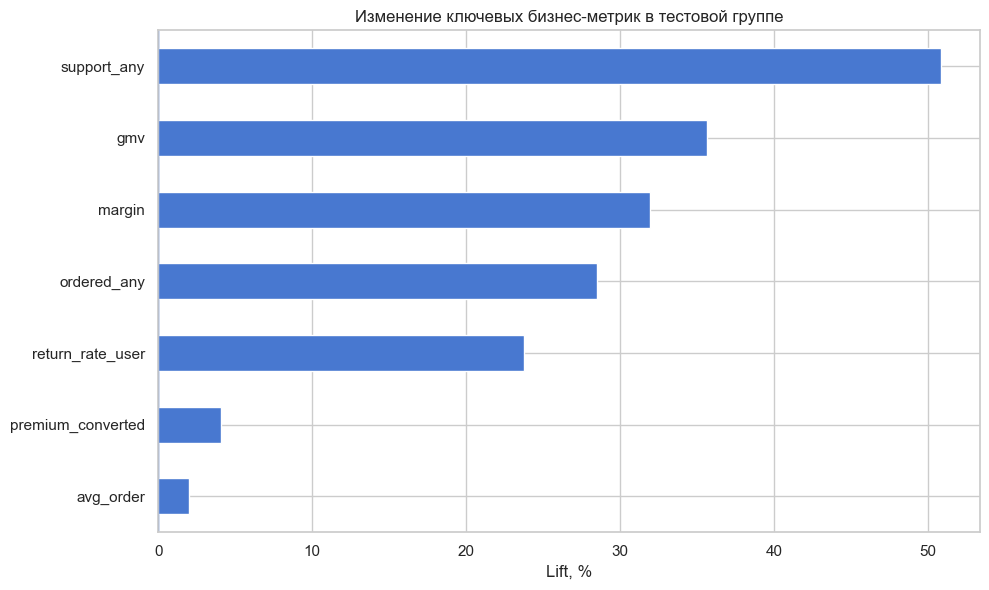

In [65]:
positive_metrics = ["ordered_any", "avg_order", "gmv", "margin", "premium_converted"]
negative_metrics = ["return_rate_user", "support_any"]

recommendation_plot = pd.concat([
    recommendation_summary.loc[positive_metrics, "lift_pct"].rename("Положительные метрики"),
    recommendation_summary.loc[negative_metrics, "lift_pct"].rename("Риски")
])

plt.figure(figsize=(10, 6))
recommendation_plot.sort_values().plot(kind="barh")
plt.axvline(0, linewidth=1)
plt.title("Изменение ключевых бизнес-метрик в тестовой группе")
plt.xlabel("Lift, %")
plt.ylabel("")
plt.tight_layout()
plt.show()

### 7.2. Сравнение эффекта по сегментам

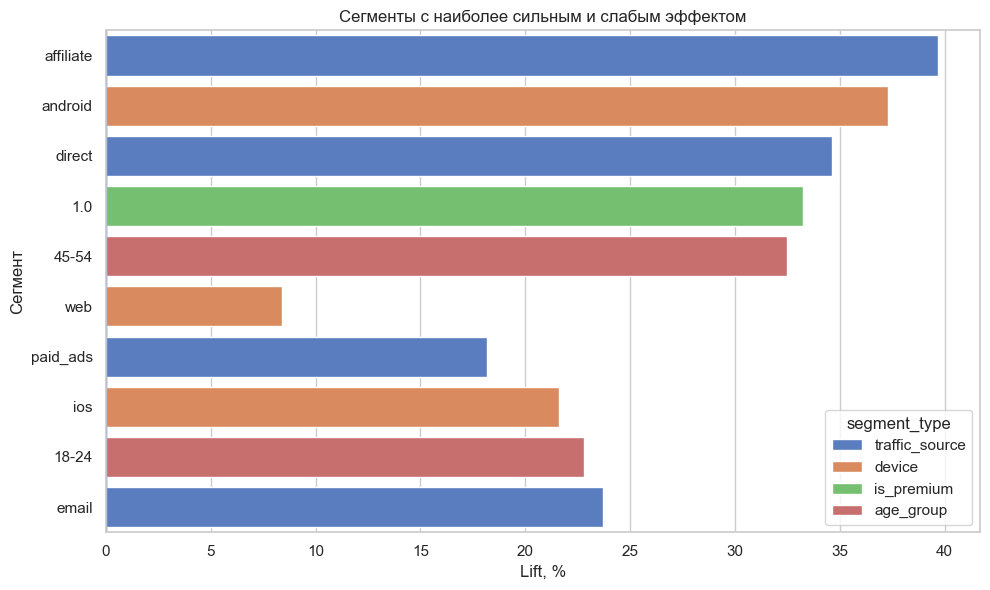

In [66]:
segment_plot = pd.concat([
    segment_summary.sort_values("lift_pct", ascending=False).head(5),
    segment_summary.sort_values("lift_pct").head(5)
]).drop_duplicates()

plt.figure(figsize=(10, 6))
sns.barplot(data=segment_plot, x="lift_pct", y="segment", hue="segment_type")
plt.axvline(0, linewidth=1)
plt.title("Сегменты с наиболее сильным и слабым эффектом")
plt.xlabel("Lift, %")
plt.ylabel("Сегмент")
plt.tight_layout()
plt.show()

### 7.3. Формализация решения


In [67]:
main_positive = recommendation_summary.loc[
    ["ordered_any", "avg_order", "gmv", "margin"],
    "lift_pct"
].mean()

return_lift = recommendation_summary.loc["return_rate_user", "lift_pct"]
support_lift = recommendation_summary.loc["support_any", "lift_pct"]

print(f"Средний рост основных бизнес-метрик: {main_positive:.1f}%")
print(f"Рост возвратов: {return_lift:.1f}%")
print(f"Рост обращений в поддержку: {support_lift:.1f}%")

Средний рост основных бизнес-метрик: 24.5%
Рост возвратов: 23.8%
Рост обращений в поддержку: 50.8%


## Следует ли внедрять модель для всех пользователей?

Результаты A/B-теста показывают статистически значимый положительный эффект новой рекомендательной модели по основным продуктовым и финансовым показателям.

Наиболее существенными являются рост конверсии в покупку, среднего размера заказа, GMV и валовой прибыли на пользователя.

Сегментационный анализ при этом показывает, что величина эффекта различается между группами пользователей. Поэтому модель целесообразно масштабировать, но одновременно организовать мониторинг эффективности по ключевым сегментам.

На текущем этапе рекомендуется перейти к более широкому внедрению модели, сохранив контрольную группу или механизм мониторинга для оценки эффекта после масштабирования.

## Следующий этап эксперимента

Следующим этапом рекомендуется провести эксперимент, направленный на оптимизацию модели с учётом не только вероятности клика и покупки, но и качества получаемого заказа.

В качестве основной метрики следует использовать маржу на пользователя (`margin`), поскольку именно она непосредственно отражает экономическую ценность пользователя для компании.

Дополнительными метриками следует оставить GMV, конверсию в покупку, средний размер заказа, долю повторных покупателей, возвраты и обращения в поддержку.

Отдельно рекомендуется проверить варианты модели для сегментов, в которых эффект оказался наиболее слабым. Это позволит определить, можно ли дополнительно увеличить эффективность рекомендаций без ухудшения качества пользовательского опыта.

При масштабировании модели необходимо учитывать следующие риски:

1. **Рост возвратов.** Доля пользователей с возвратами увеличилась примерно на 59%. Необходимо проверить, какие категории товаров и сегменты пользователей формируют основной вклад в данный рост.

2. **Рост обращений в поддержку.** Доля пользователей, обращавшихся в службу поддержки, выросла примерно на 51%. Следует проверить причины обращений и определить, связаны ли они непосредственно с рекомендованными товарами.

3. **Неоднородность эффекта.** Сегментационный анализ показывает, что модель работает с разной эффективностью для различных устройств, возрастных групп и источников трафика. Средний эффект по всей аудитории может скрывать слабые или отрицательные результаты отдельных сегментов.

4. **Изменение эффекта после масштабирования.** При переходе от экспериментальной выборки к полной аудитории поведение пользователей и нагрузка на систему могут измениться. Поэтому после внедрения необходим постоянный мониторинг ключевых метрик.

## Дополнительные исследования

Перед окончательным масштабированием рекомендуется провести следующие дополнительные исследования:

- определить категории товаров, которые сильнее всего влияют на рост возвратов;
- исследовать причины обращений в поддержку в тестовой группе;
- проверить устойчивость эффекта по регионам, устройствам, возрастным группам и источникам трафика;
- оценить долгосрочную динамику повторных покупок;
- проверить, сохраняется ли рост маржи после учёта дополнительных затрат, связанных с возвратами и обслуживанием пользователей;
- провести дополнительный анализ сегментов с наиболее низким эффектом;
- продолжить мониторинг результатов после внедрения модели.

## Итоговая рекомендация

Новая рекомендательная модель продемонстрировала статистически значимое улучшение ключевых продуктовых и финансовых показателей. Наиболее существенными результатами являются рост конверсии в покупку, среднего размера заказа, GMV и валовой прибыли на пользователя.

С учётом полученного положительного бизнес-эффекта модель рекомендуется к дальнейшему масштабированию.

При этом внедрение должно сопровождаться контролем возвратов и обращений в поддержку, поскольку данные показатели также статистически значимо увеличились.

Оптимальной стратегией является поэтапное масштабирование с сохранением возможности оперативного контроля ключевых метрик. На следующем этапе рекомендуется оптимизировать модель с учётом не только вероятности покупки, но и её экономической ценности, используя маржу на пользователя в качестве одной из основных целевых метрик.

Таким образом, решение о внедрении является положительным, но должно сопровождаться постоянным мониторингом качества заказов, пользовательского опыта и финансового эффекта.

# 8. Дополнительные данные

**1. Детализация возвратов**

Необходимо получить информацию о причинах возвратов, категориях возвращаемых товаров и связи возврата с рекомендованным товаром.

Это позволит определить, действительно ли рост `return_rate_user` связан с новой рекомендательной моделью и не приводит ли увеличение продаж к ухудшению качества покупок.

**2. Детализация обращений в поддержку**

Желательно получить причины обращений пользователей в службу поддержки, их категории и связь с заказами из тестовой группы.

Это необходимо для оценки того, связан ли рост `support_any` с работой рекомендательной системы или вызван другими факторами.

**3. Данные о затратах**

Необходимо получить информацию о дополнительных операционных затратах, связанных с обработкой заказов, возвратов и обращений в поддержку.

Это позволит перейти от оценки `GMV` и `margin` к более точной оценке дополнительной прибыли, создаваемой моделью.

**4. Долгосрочное поведение пользователей**

Необходимо получить более продолжительную историю покупок после окончания эксперимента.

Это позволит проверить, сохраняется ли наблюдаемый рост `repeat_any` в долгосрочной перспективе.

**5. Данные о показах и рекомендациях**

Желательно получить информацию о том, какие именно товары рекомендовались пользователям, а также характеристики этих рекомендаций.

Это позволит определить, какие типы рекомендаций формируют основной положительный эффект и какие из них могут приводить к повышенной доле возвратов.

**6. Дополнительная детализация по сегментам**

Перед окончательным масштабированием желательно получить более подробные характеристики пользователей и заказов для сегментов, в которых эффект модели существенно различается.

Это позволит определить причины неоднородности эффекта и адаптировать модель под отдельные группы пользователей.